# Pilot 2025 Aroma Model Selection and MBDoE

This notebook documents the model-structure iteration used to improve the aroma layer for the pilot-scale natural-must dataset. The goal is not only to reduce error, but to choose a structure that is interpretable, numerically identifiable, and useful for future model-based experimental design.

## Workflow

1. Load the curated pilot dataset, including the `25171` effective start correction at `t_original = 100 h`.
2. Keep the calibrated primary fermentation, glycerol, and secondary v2 model as the current prior.
3. Fit several aroma kinetic variants that differ only in the ethyl-acetate production structure.
4. Compare variants using weighted residual error, AICc/BIC, active-bound diagnostics, and ethyl-acetate retained-pool bias.
5. Recompute the local Fisher information matrix for the selected structure.
6. Evaluate candidate natural-must designs using FIM accumulation and select an optimal campaign with a hybrid criterion.

## Observation Model

For each aroma species `i`, the workbook contains total aroma and condenser-equivalent aroma:

$$C_{total,i}^{obs}=C_{wine,i}^{obs}+C_{cond,i}^{obs}$$

so the retained liquid concentration fitted by the ODE is

$$C_{wine,i}^{obs}=C_{total,i}^{obs}-C_{cond,i}^{obs}.$$

This reconstruction is applied only when the condenser-equivalent value is positive. Exact zero entries in the condenser columns are treated as missing or below-reporting-limit records, because the condenser behaves as an accumulated trap rather than a continuously sampled online analyzer. When total aroma is available but positive condenser information is not, the fitted observation is `C_total = C_L + C_cond`.

The model states are

$$x_{a,i}=\left[C_{L,i}, C_{cond,i}\right]^T$$

with dynamics

$$\frac{dC_{L,i}}{dt}=r_{prod,i}-r_{loss,i}, \qquad \frac{dC_{cond,i}}{dt}=r_{loss,i}.$$

Volatilization is kept common across variants and follows the CO2-stripping balance used in the Mouret-style aroma partition framework:

$$r_{loss,i}=\alpha_i K_i(T,E)q_{CO2}C_{L,i}.$$

In this run, `K_i` is not fitted. It is computed as

$$K_i(T,E)=\frac{\gamma_i^{UNIFAC}(T,x_{water},x_{ethanol})P_i^{sat,Antoine}(T)}{RT C_{tot,L}}$$

where `gamma_i` is the infinite-dilution activity coefficient from original UNIFAC for the water-ethanol mixture, `P_i^{sat}` is calculated from Antoine coefficients, and `C_{tot,L}` is the total liquid molar concentration. `alpha_i` remains an effective capture/loss scaling parameter estimated from the condenser data. The audit tables `partition_antoine_coefficients.csv` and `partition_antoine_unifac_audit.csv` document the thermodynamic inputs.

## Candidate Kinetic Structures

### `baseline_phase`

Original phase-dependent aroma model used in the previous pilot calibration.

$$r_{EA}=\left(k_{EA,g}\phi_N+k_{EA,s}(1-\phi_N)\right)q_S$$

Reference empirical model: aroma synthesis is tied to sugar uptake and split between nitrogen-associated growth and stationary phases; volatilization is CO2-rate dependent.

### `ea_biomass_background`

Tests whether ethyl acetate behaves as a biomass/activity output rather than a direct sugar-rate output.

$$r_{EA}=r_{EA,phase}+k_{EA,X}X$$

Adds a biomass-associated ethyl-acetate formation term, representing acetyltransferase capacity and natural-must precursor availability not captured by sugar uptake alone.

### `ea_ethanol_biomass`

Tests whether the missing ethyl-acetate source is ethanol/biomass dependent.

$$r_{EA}=r_{EA,phase}+k_{EA,XE}X\frac{E}{K_E+E}$$

Ethyl acetate formation requires ethanol as the alcohol precursor. This variant adds a saturating ethanol-biomass term while keeping volatilization unchanged.

### `ea_ethanol_temperature`

Tests whether the missing ethyl-acetate source is mainly temperature-modulated.

$$r_{EA}=r_{EA,phase}+k_{EA,XE}X\frac{E}{K_E+E}q_{10,EA}^{(T-20)/10}$$

Fermentative ester synthesis and stripping are temperature-sensitive. This variant lets the ethanol-biomass production term follow a fitted Q10 factor around 20 C.

### `ea_ethanol_nlimited`

Tests whether ethyl acetate increases when ethanol is available and nitrogen is depleted.

$$r_{EA}=r_{EA,phase}+k_{EA,XE}X\frac{E}{K_E+E}+k_{EA,XE,Nlim}X\frac{E}{K_E+E}\frac{K_N}{K_N+N}$$

Nitrogen limitation changes yeast aroma metabolism. This variant separates a baseline ethanol-biomass source from an additional nitrogen-limited source.

### `ea_redox_acetaldehyde`

Tests whether secondary redox chemistry explains the ethyl-acetate deficit.

$$r_{EA}=r_{EA,phase}+k_{EA,XE}X\frac{E}{K_E+E}+k_{EA,AcAld}X\frac{AcAld}{K_{AcAld}+AcAld}\frac{E}{K_E+E}$$

Ethyl acetate is linked to acetyl-CoA/redox and acetaldehyde/acetate-side metabolism. The reduced secondary model provides acetaldehyde as a proxy state.

### `ea_combined_parsimonious`

Upper-complexity check for whether several mechanistic proxies are simultaneously needed.

$$r_{EA}=r_{EA,phase}+k_{EA,X}X+k_{EA,XE}X\frac{E}{K_E+E}+k_{EA,AcAld}X\frac{AcAld}{K_{AcAld}+AcAld}\frac{E}{K_E+E}$$

A compact combined model: background biomass capacity, ethanol precursor availability, and acetaldehyde/redox proxy. This is the largest variant considered here and is penalized by BIC/AICc.

## Statistical Criteria

Let `r(theta)` be the weighted residual vector. The data-only weighted sum of squared errors is

$$WSSE= r(\theta)^T r(\theta).$$

For model comparison, the notebook reports

$$AIC_c = WSSE + 2k + \frac{2k(k+1)}{n-k-1},$$

$$BIC = WSSE + k\log(n),$$

where `k` is the number of fitted aroma parameters and `n` is the number of aroma residuals. Because ethyl acetate is the priority output and the previous structure showed systematic underprediction, ethyl-acetate residuals are weighted twice as strongly as the other aroma residuals in the fitting objective. The final selection score is BIC plus penalties for active bounds and unacceptable ethyl-acetate retained-pool bias/RMSE. This prevents selection of a flexible model that only improves the global objective while still failing the main problematic output.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display
cwd = Path.cwd()
if (cwd / 'results' / 'aroma_model_selection_doe').exists():
    RESULTS = cwd / 'results' / 'aroma_model_selection_doe'
else:
    RESULTS = cwd / 'fermentation_model' / 'pilot_2025' / 'results' / 'aroma_model_selection_doe'
model_summary = pd.read_csv(RESULTS / 'model_selection_summary.csv')
variant_metrics = pd.read_csv(RESULTS / 'variant_pool_metrics.csv')
theta = pd.read_csv(RESULTS / 'theta_selected_aroma_model.csv', index_col=0)
estimability = pd.read_csv(RESULTS / 'parameter_estimability_selected_current.csv')
weak = pd.read_csv(RESULTS / 'weak_directions_selected_current.csv')
ranking = pd.read_csv(RESULTS / 'candidate_ranking_selected_model.csv')
campaign = pd.read_csv(RESULTS / 'selected_campaign_hybrid_selected_model.csv')
model_summary.sort_values('selection_score')

,model,n_parameters,data_wsse,wsse_per_data_residual,n_data_residuals,aicc,bic,active_bound_count,ea_retained_rmse,ea_retained_relative_rmse,...,ea_retained_abs_relative_bias,ea_total_rmse,ea_total_relative_rmse,ea_total_relative_bias,ea_total_abs_relative_bias,description,literature_basis,selected,selection_penalty,selection_score
0,ea_ethanol_nlimited,11,7369.836459,28.236921,261,7392.896700,7431.046184,2,4.777061,0.575972,...,0.437476,3.615508,0.476356,-0.285364,0.285364,Tests whether ethyl acetate increases when eth...,Nitrogen limitation changes yeast aroma metabo...,True,46.998115,7478.044299
1,ea_redox_acetaldehyde,11,7493.343817,28.710130,261,7516.404058,7554.553541,2,5.058525,0.609909,...,0.467280,3.693856,0.486679,-0.292988,0.292988,Tests whether secondary redox chemistry explai...,Ethyl acetate is linked to acetyl-CoA/redox an...,False,49.382394,7603.935935
2,ea_combined_parsimonious,12,7490.274055,28.698368,261,7515.532120,7557.048300,3,5.060760,0.610178,...,0.467516,3.695652,0.486915,-0.293037,0.293037,Upper-complexity check for whether several mec...,A compact combined model: background biomass c...,False,69.401277,7626.449577
3,ea_ethanol_biomass,10,7696.917575,29.490106,261,7717.797575,7752.562779,2,4.619212,0.556940,...,0.424286,3.499288,0.461044,-0.279789,0.279789,Tests whether the missing ethyl-acetate source...,Ethyl acetate formation requires ethanol as th...,False,45.942868,7798.505648
4,ea_ethanol_temperature,11,7696.933600,29.490167,261,7719.993841,7758.143324,3,4.619204,0.556939,...,0.424285,3.499281,0.461043,-0.279788,0.279788,Tests whether the missing ethyl-acetate source...,Fermentative ester synthesis and stripping are...,False,65.942760,7824.086085
5,ea_biomass_background,10,8249.506452,31.607304,261,8270.386452,8305.151656,2,4.450727,0.536626,...,0.410357,3.352808,0.441744,-0.273907,0.273907,Tests whether ethyl acetate behaves as a bioma...,Adds a biomass-associated ethyl-acetate format...,False,44.828544,8349.980201
6,baseline_phase,9,9448.983870,36.203003,261,9467.701001,9499.064554,2,4.259876,0.513615,...,0.376019,3.249062,0.428075,-0.281470,0.281470,Original phase-dependent aroma model used in t...,Reference empirical model: aroma synthesis is ...,False,42.081520,9541.146074


## Selected Parameter Vector

In [2]:
theta

,0
mu0,0.068971
sN,8.751446
qN,0.015772
qXG,0.081491
qXF,0.070933
betaG0,1.186336
sG,0.097455
betaF0,0.314510
sF,0.178295
qEG,1.112514


## Pool-Level Fit Metrics

In [3]:
variant_metrics.sort_values(['model', 'species', 'pool']).head(80)

,species,pool,n,rmse,mae,bias,median_obs,median_pred,relative_rmse_to_median,relative_bias_to_median,model
0,ethyl_acetate,condensate,17,0.100048,0.091531,0.091531,0.012473,0.096718,8.021322,7.338423,baseline_phase
1,ethyl_acetate,retained,17,4.259876,3.357624,-3.118667,8.293908,5.728684,0.513615,-0.376019,baseline_phase
2,ethyl_acetate,total,52,3.249062,2.274188,-2.136335,7.589931,5.209708,0.428075,-0.281470,baseline_phase
3,ethyl_octanoate,condensate,44,0.009953,0.006075,-0.003602,0.012386,0.010935,0.803593,-0.290786,baseline_phase
4,ethyl_octanoate,retained,44,0.022403,0.015624,-0.006155,0.034524,0.035407,0.648916,-0.178294,baseline_phase
...,...,...,...,...,...,...,...,...,...,...,...
49,ethyl_octanoate,retained,44,0.022399,0.015625,-0.006146,0.034524,0.035437,0.648791,-0.178025,ea_redox_acetaldehyde
50,ethyl_octanoate,total,52,0.025197,0.016431,-0.008254,0.044668,0.043299,0.564104,-0.184798,ea_redox_acetaldehyde
51,isoamyl_acetate,condensate,44,0.566955,0.323689,-0.259249,0.479512,0.305919,1.182358,-0.540651,ea_redox_acetaldehyde
52,isoamyl_acetate,retained,44,1.900979,1.392912,-0.753859,5.203077,4.938099,0.365357,-0.144887,ea_redox_acetaldehyde


## Model-Comparison Plot

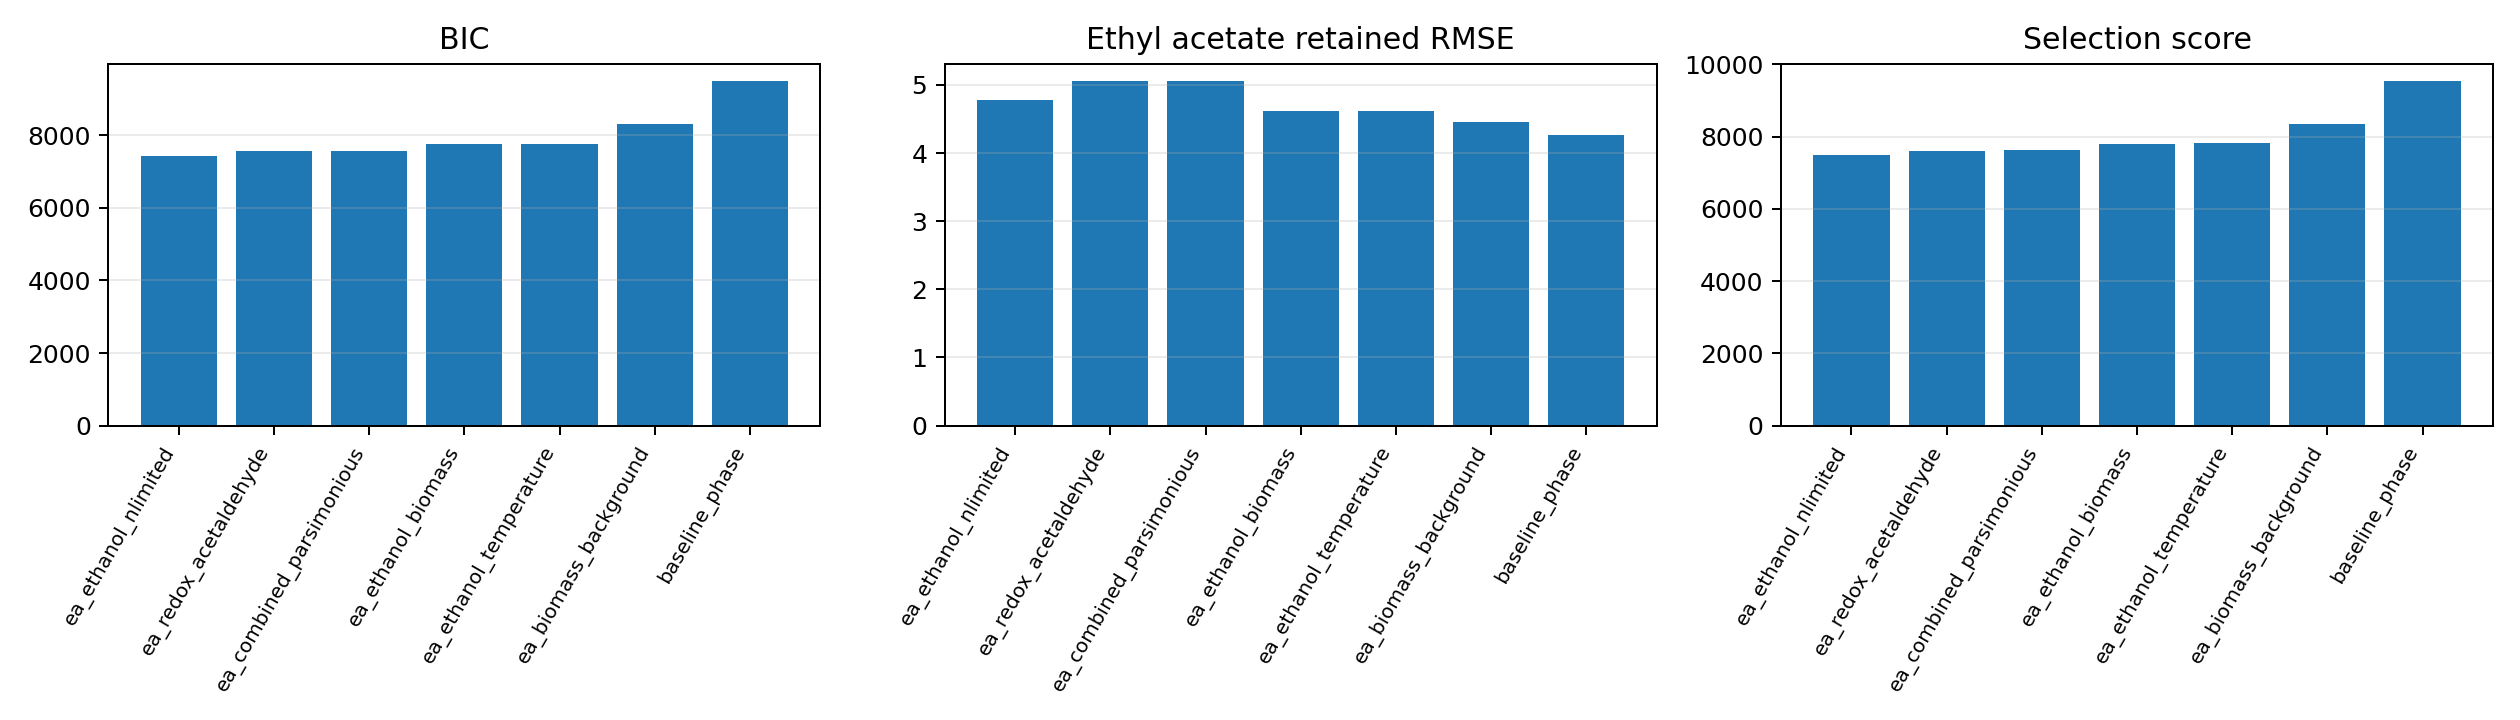

In [4]:
plot = RESULTS / 'plots' / 'model_selection_comparison.png'
display(Image(filename=str(plot)))

## Selected Structure: `ea_ethanol_nlimited`

Tests whether ethyl acetate increases when ethanol is available and nitrogen is depleted.

$$r_{EA}=r_{EA,phase}+k_{EA,XE}X\frac{E}{K_E+E}+k_{EA,XE,Nlim}X\frac{E}{K_E+E}\frac{K_N}{K_N+N}$$

Interpretation: this is the simplest structure that best balances ethyl-acetate fit, global aroma error, parameter parsimony, and numerical diagnostics.

## Fisher Information Matrix

The local sensitivity matrix is computed by centered finite differences in log-parameter space:

$$J_{m,j}=\frac{r_m(\theta_j e^{h})-r_m(\theta_j e^{-h})}{2h}.$$

The Fisher information matrix is then

$$F = J^T J.$$

Because perturbations are performed in log-parameter space, the covariance approximation is also in log-parameter units. The reported `approx_95_multiplier` is `exp(1.96 sigma_log)`.

In [5]:
estimability.sort_values('std_log_approx', ascending=False)

,analysis,parameter,theta,std_log_approx,approx_95_multiplier,fim_diag,active_bound,classification
17,selected_current,kAcStress,0.002616,363.611346,1.057654e+17,0.000000,False,weak_or_confounded
27,selected_current,k_EA_XE,0.000011,362.608751,1.057654e+17,0.000202,False,weak_or_confounded
18,selected_current,k_EA_growth,0.000100,90.248739,1.057654e+17,0.000866,True,weak_or_confounded
15,selected_current,kAldRed,0.000010,15.385669,1.248952e+13,0.018218,True,weak_or_confounded
10,selected_current,gammaF0,0.003394,2.006693,5.106593e+01,18.373937,False,weak_or_confounded
19,selected_current,k_EA_stationary,0.005947,0.455476,2.441792e+00,69.864607,False,moderate
12,selected_current,kPyrO2,0.152368,0.292818,1.775219e+00,470.564964,False,well_estimated
3,selected_current,betaF0,0.314510,0.211288,1.513046e+00,3948.789256,False,well_estimated
6,selected_current,iG,0.013971,0.204639,1.493455e+00,1556.770014,False,well_estimated
23,selected_current,k_EO_stationary,0.000150,0.180195,1.423592e+00,136.272594,False,well_estimated


## Weak Eigen-Directions

In [6]:
weak

,analysis,weak_direction,eigenvalue,dominant_parameters,dominant_abs_loadings
0,selected_current,1,-6.374047e-14,"kAcStress, k_EA_XE, k_EA_growth, k_EA_XE_Nlim,...","1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.00..."
1,selected_current,2,1.883644e-08,"k_EA_XE, k_EA_growth, k_EA_XE_Nlim, kAldRed, k...","0.998, 0.057, 0.000, 0.000, 0.000, 0.000, 0.00..."
2,selected_current,3,1.215477e-04,"k_EA_growth, k_EA_XE, k_EA_stationary, kAldRed...","0.998, 0.057, 0.003, 0.001, 0.000, 0.000, 0.00..."
3,selected_current,4,4.216896e-03,"kAldRed, kAcAld, gammaF0, k_EA_growth, iG, bet...","1.000, 0.002, 0.001, 0.001, 0.001, 0.001, 0.00..."
4,selected_current,5,2.477561e-01,"gammaF0, gammaG0, betaF0, iG, qEF, iE, qEG, k_...","0.999, 0.041, 0.021, 0.015, 0.009, 0.008, 0.00..."
5,selected_current,6,6.838299e+00,"k_EA_stationary, k_EA_XE_Nlim, alpha_EA_loss, ...","0.989, 0.122, 0.076, 0.020, 0.019, 0.010, 0.00..."
6,selected_current,7,9.112397e+00,"kPyrO2, kPyrDrain, kPyrS_N, iG, betaF0, k_EA_s...","0.882, 0.443, 0.153, 0.033, 0.027, 0.022, 0.01..."
7,selected_current,8,1.201741e+01,"betaF0, iG, qEF, iE, gammaG0, qEG, kPyrO2, gam...","0.650, 0.627, 0.327, 0.230, 0.108, 0.092, 0.04..."


## MBDoE Criterion

Candidate experiments are evaluated by adding their expected FIM to the current-data FIM:

$$F_{combined}=F_{current}+\sum_{e \in \mathcal{E}}F_e.$$

The ranking reports D-optimality through `logdet(F)`, E-like robustness through the minimum relative eigenvalue, and A-like behavior through `trace(inv(F))`. The selected campaign uses the hybrid score

$$\Phi_{hybrid}=\log\det(F)+2\log(\lambda_{min}/\lambda_{max})-0.05\log(\mathrm{trace}(F^{-1})).$$

This keeps the D-optimal volume objective but discourages designs that leave a nearly unobservable direction.

In [7]:
cols = ['candidate', 'family', 'combined_logdet', 'combined_min_relative_eigenvalue', 'aroma_mean_var_reduction', 'aroma_worst_var_reduction', 'N_pulses_kg_m3', 'rationale']
ranking[cols].head(12)

,candidate,family,combined_logdet,combined_min_relative_eigenvalue,aroma_mean_var_reduction,aroma_worst_var_reduction,N_pulses_kg_m3,rationale
0,natural_pilot_cold_to_warm_earlyN,temperature_N,139.125494,1.592160e-12,0.240712,0.098599,30h:0.045,Cold start followed by warm transition and ear...
1,natural_pilot_midN_temperature_step,temperature_N,138.995706,1.567429e-12,0.252513,0.089003,54h:0.04,Temperature step with mid-growth nitrogen pert...
2,natural_pilot_EA_cold_retention_noN,EA_retention_reference,138.743092,1.652259e-12,0.258715,0.111257,NaN,Low-temperature no-pulse comparator to decoupl...
3,natural_pilot_noN_dynamic_temperature,temperature,138.586712,1.702437e-12,0.264407,0.107629,NaN,Temperature-only perturbation for settings whe...
4,natural_pilot_two_step_N_ladder,N_timing,138.440650,1.508941e-12,0.247371,0.088219,30h:0.03; 78h:0.035,Two smaller nitrogen pulses to separate early ...
5,natural_pilot_EA_warm_early_noN,EA_temperature_Nstress,138.682876,3.255505e-13,0.269924,0.069782,NaN,Warm early natural fermentation without nutrie...
6,natural_pilot_high_rate_strip,co2_aroma,138.855427,2.739157e-13,0.259047,0.095300,30h:0.03,High-rate natural fermentation to excite CO2 s...
7,natural_pilot_EA_warm_early_lateN,EA_lateN,138.532193,3.135252e-13,0.257254,0.073257,98h:0.045,Warm early fermentation followed by late nitro...
8,natural_pilot_warm_to_cool_noN,temperature,137.995468,3.281786e-13,0.267494,0.078782,NaN,"Warm early phase to excite growth and CO2, the..."
9,natural_pilot_reference_20C,reference,138.058697,3.041587e-13,0.268911,0.112586,NaN,Natural must warmer reference to increase rate...


## Selected Campaign

In [8]:
campaign[['campaign_order', 'candidate', 'family', 'campaign_logdet', 'campaign_min_relative_eigenvalue', 'aroma_mean_var_reduction', 'aroma_worst_var_reduction', 'N_pulses_kg_m3', 'rationale']]

,campaign_order,candidate,family,campaign_logdet,campaign_min_relative_eigenvalue,aroma_mean_var_reduction,aroma_worst_var_reduction,N_pulses_kg_m3,rationale
0,1,natural_pilot_cold_to_warm_earlyN,temperature_N,139.125494,1.592160e-12,0.240712,0.098599,30h:0.045,Cold start followed by warm transition and ear...
1,2,natural_pilot_EA_cold_retention_noN,EA_retention_reference,145.785832,2.730320e-12,0.367345,0.216952,NaN,Low-temperature no-pulse comparator to decoupl...
2,3,natural_pilot_midN_temperature_step,temperature_N,150.579220,3.589484e-12,0.445493,0.273756,54h:0.04,Temperature step with mid-growth nitrogen pert...
3,4,natural_pilot_EA_warm_early_noN,EA_temperature_Nstress,154.730295,3.662310e-12,0.517194,0.325571,NaN,Warm early natural fermentation without nutrie...
4,5,natural_pilot_noN_dynamic_temperature,temperature,157.762135,4.477197e-12,0.556375,0.356110,NaN,Temperature-only perturbation for settings whe...
5,6,natural_pilot_two_step_N_ladder,N_timing,160.367912,5.110500e-12,0.586926,0.388646,30h:0.03; 78h:0.035,Two smaller nitrogen pulses to separate early ...


## Input Profiles for Selected Designs

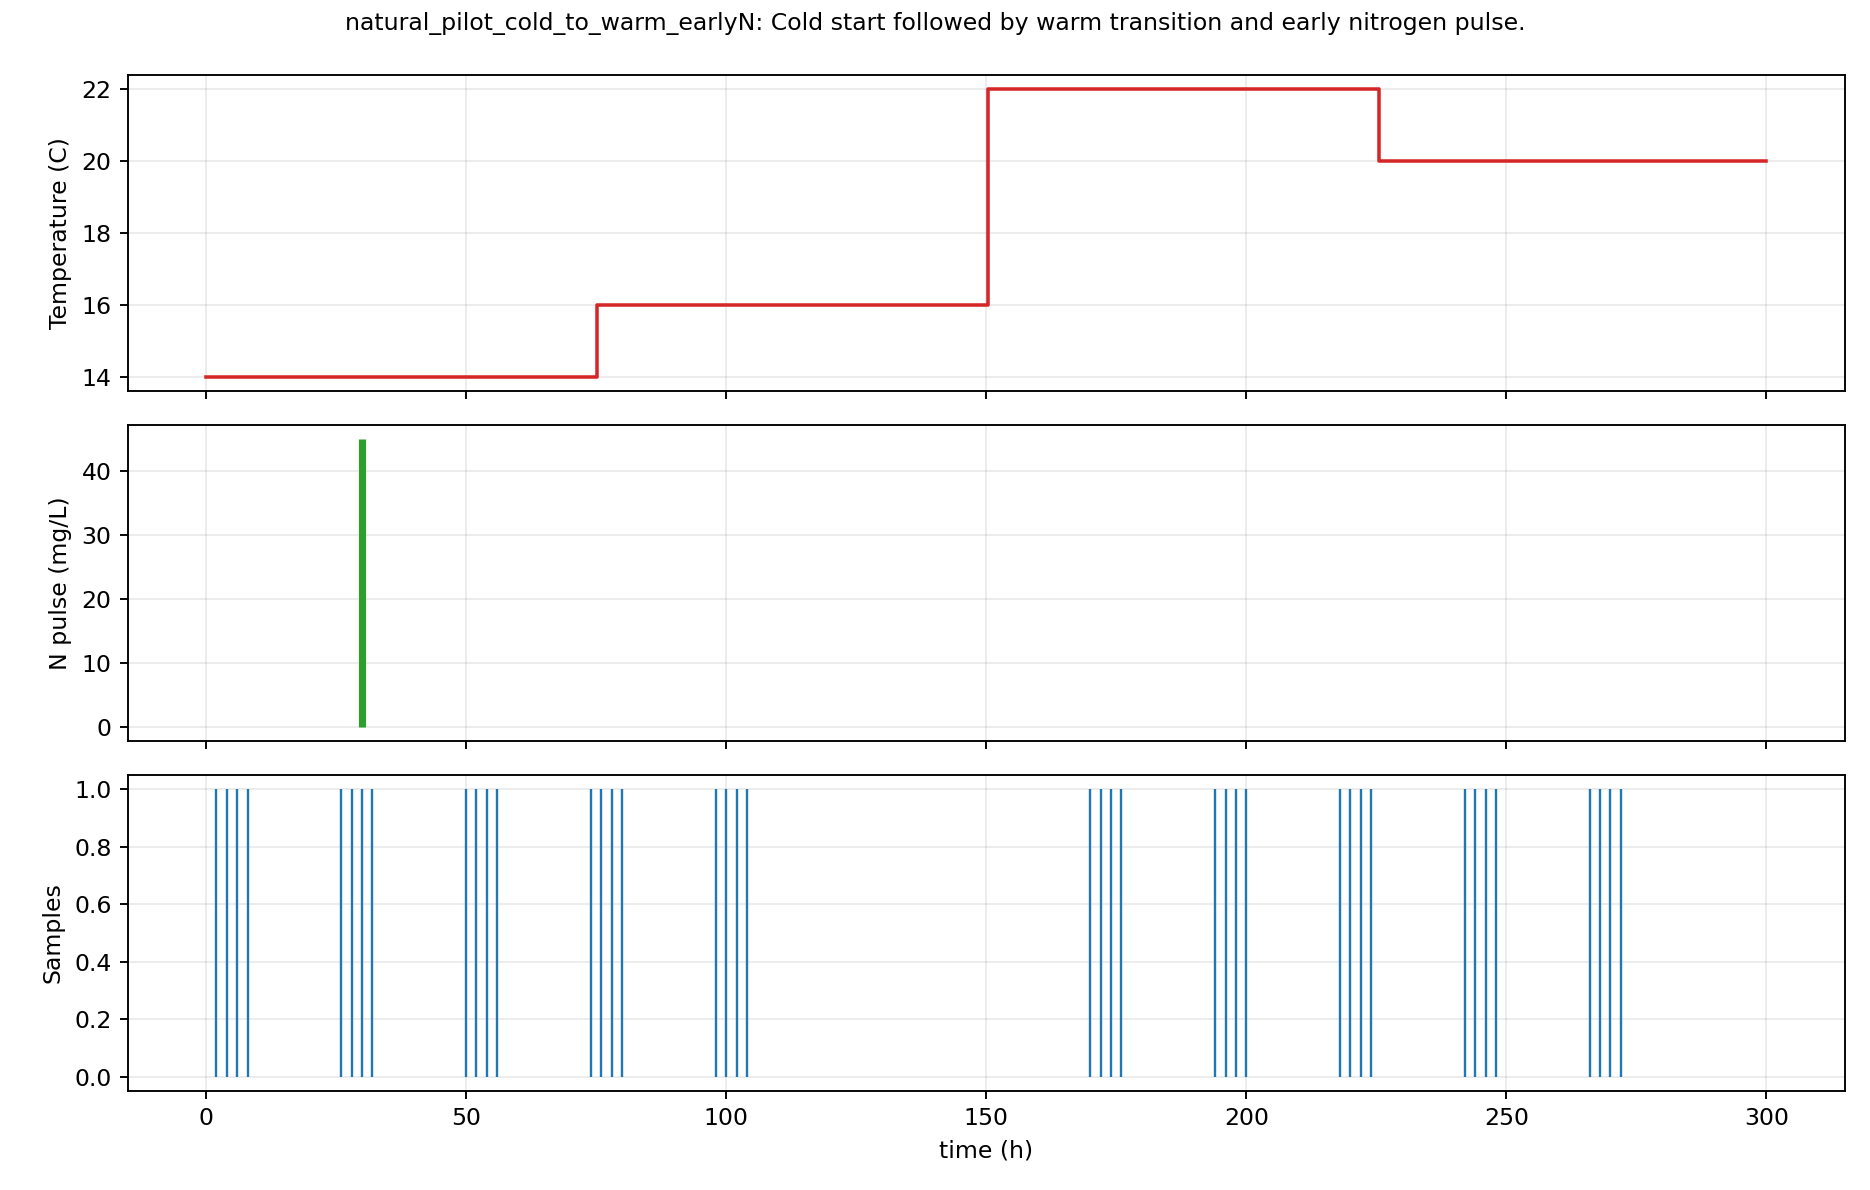

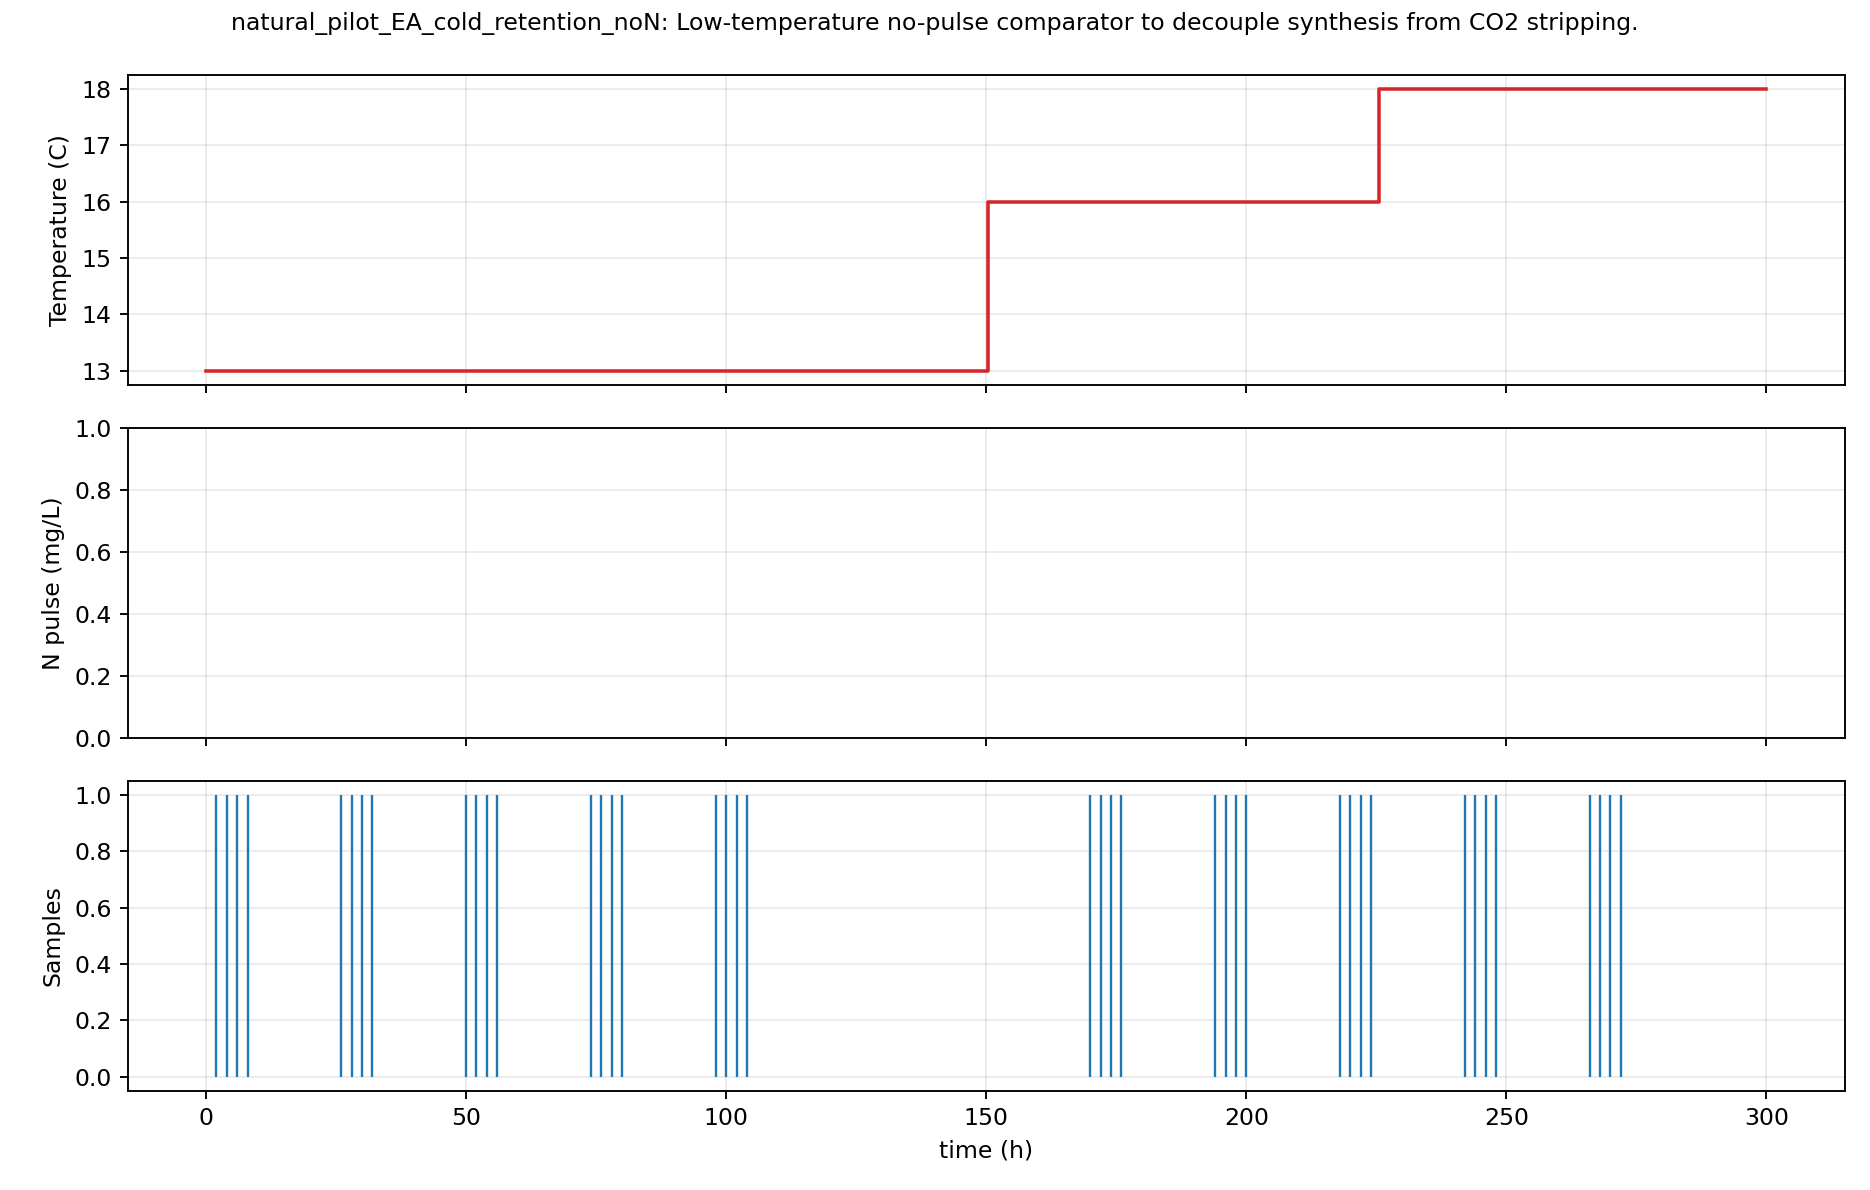

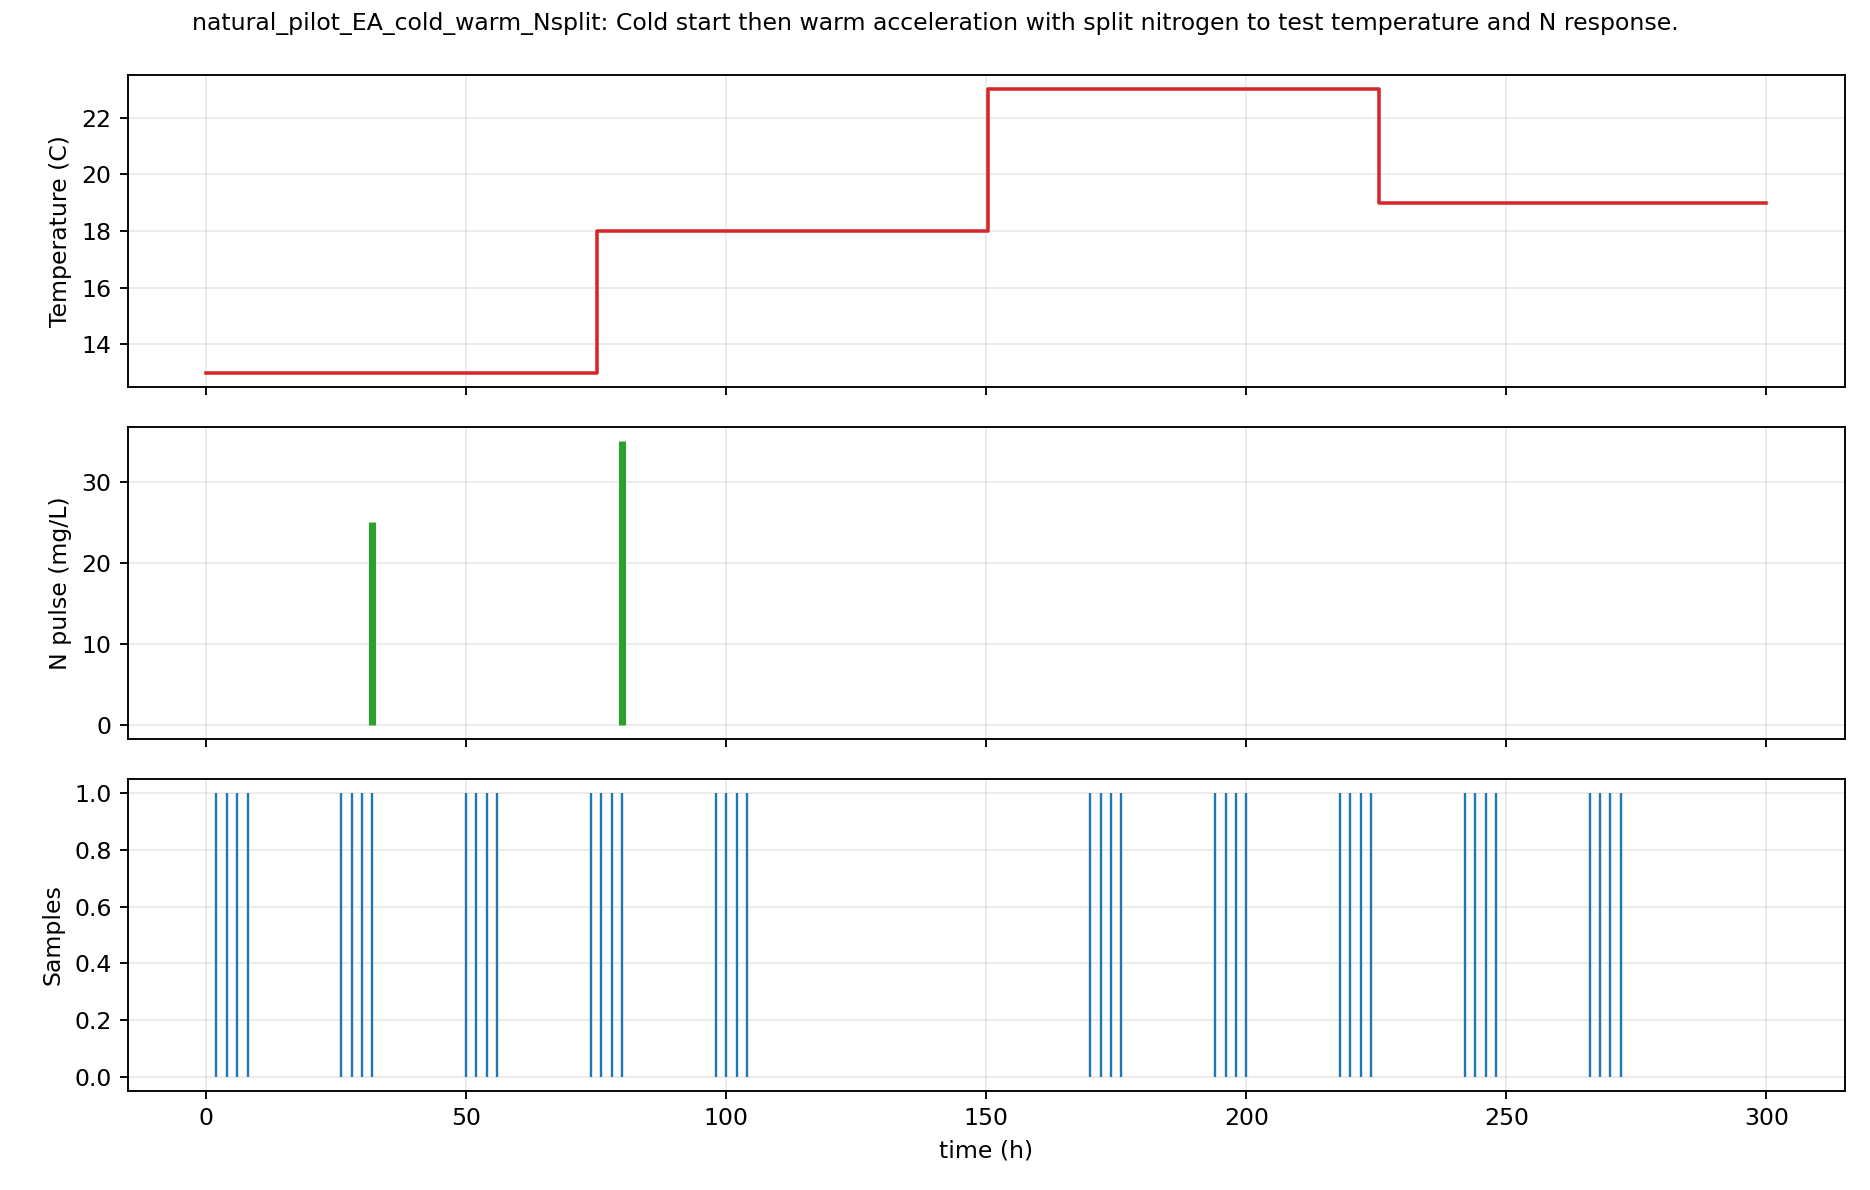

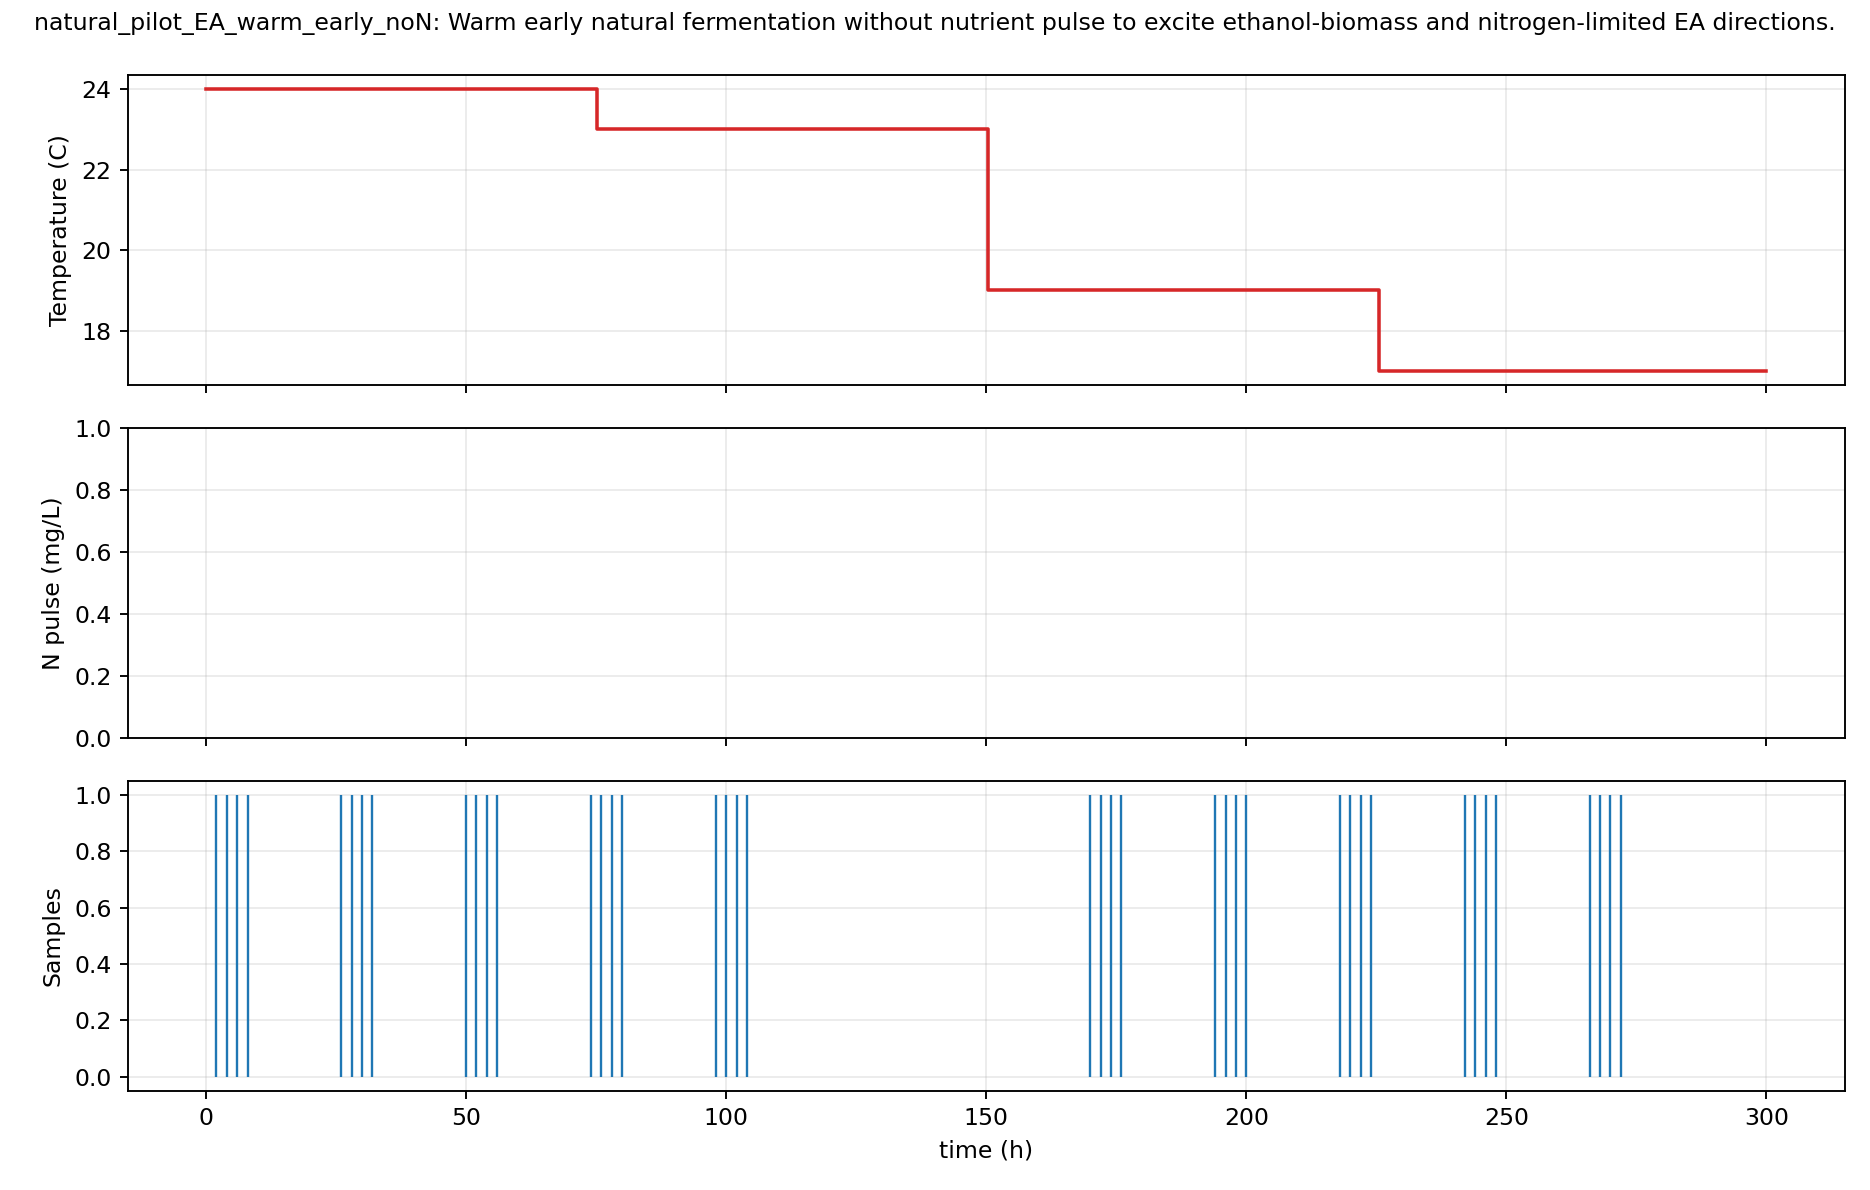

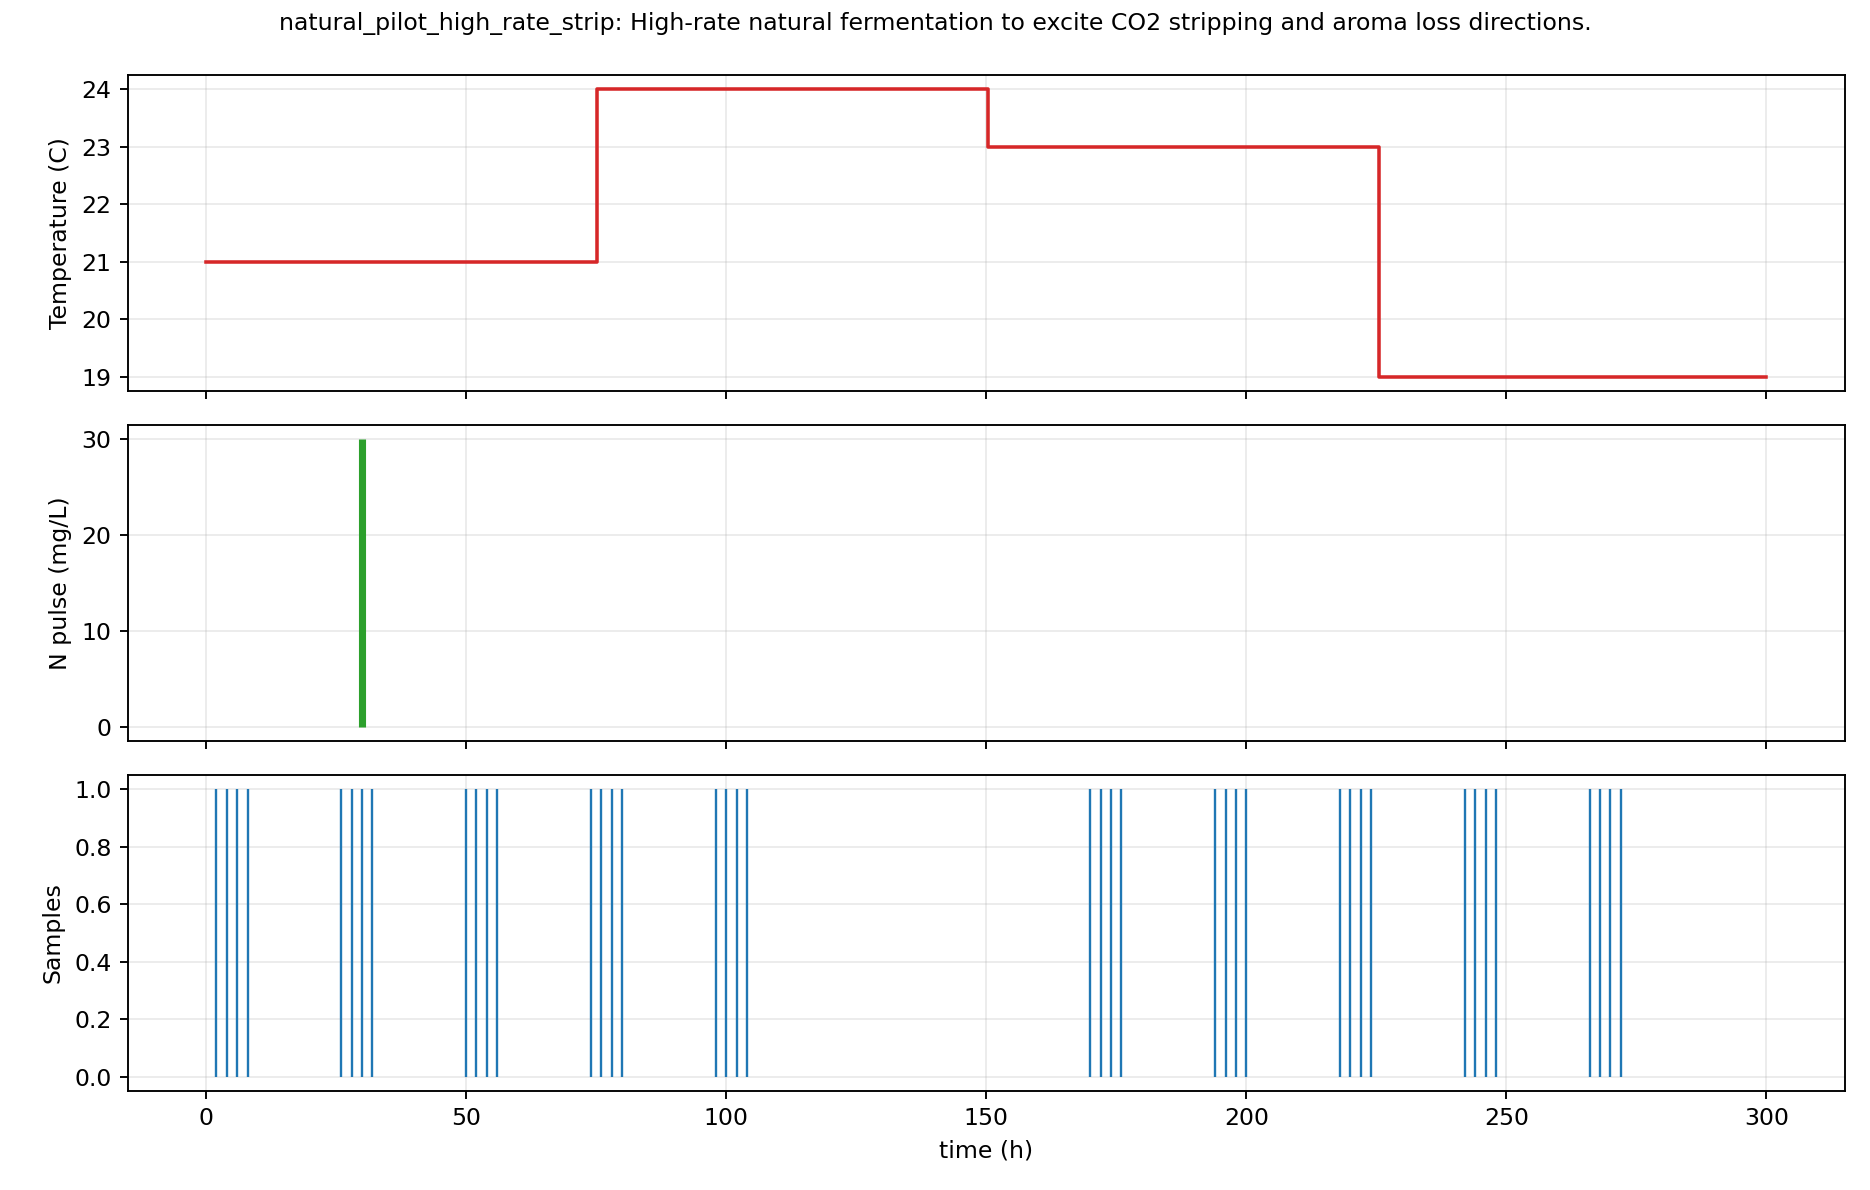

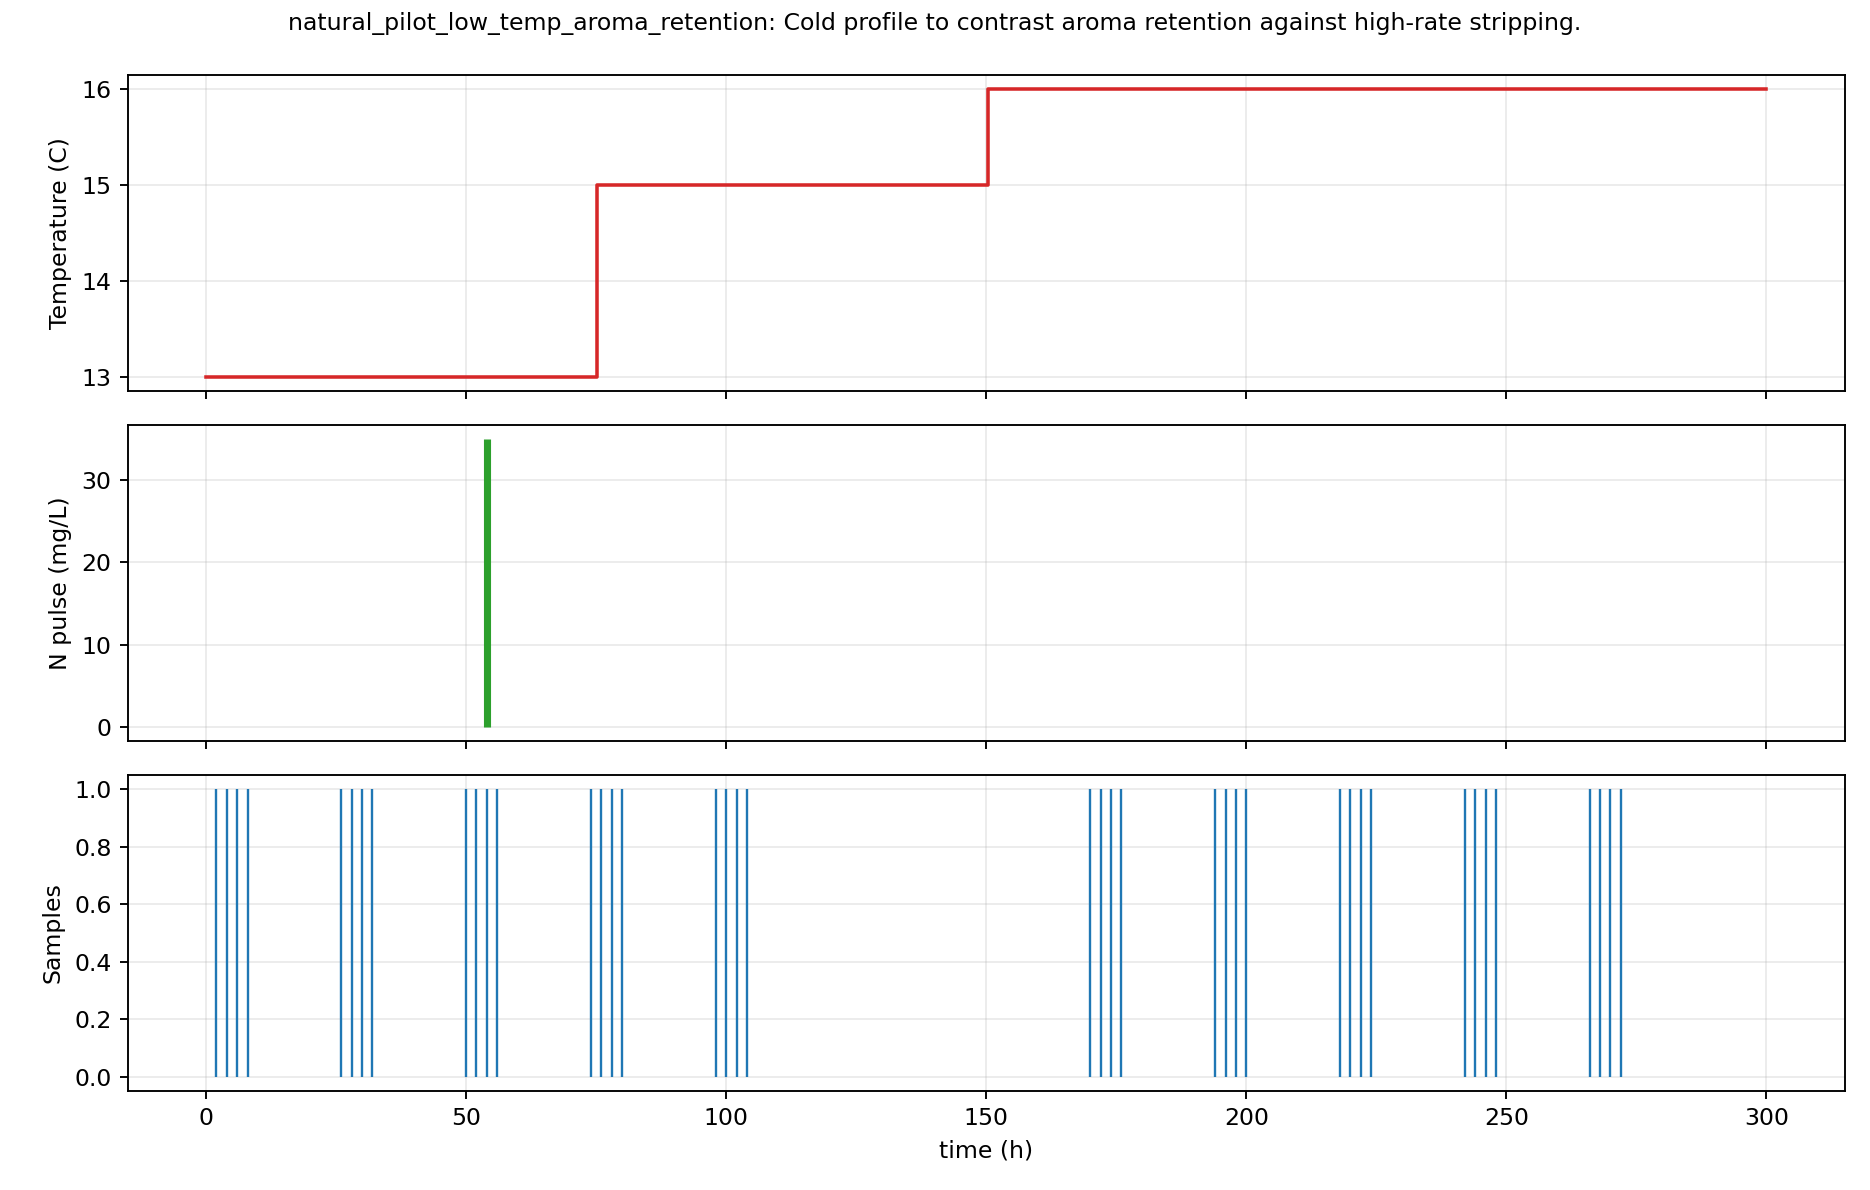

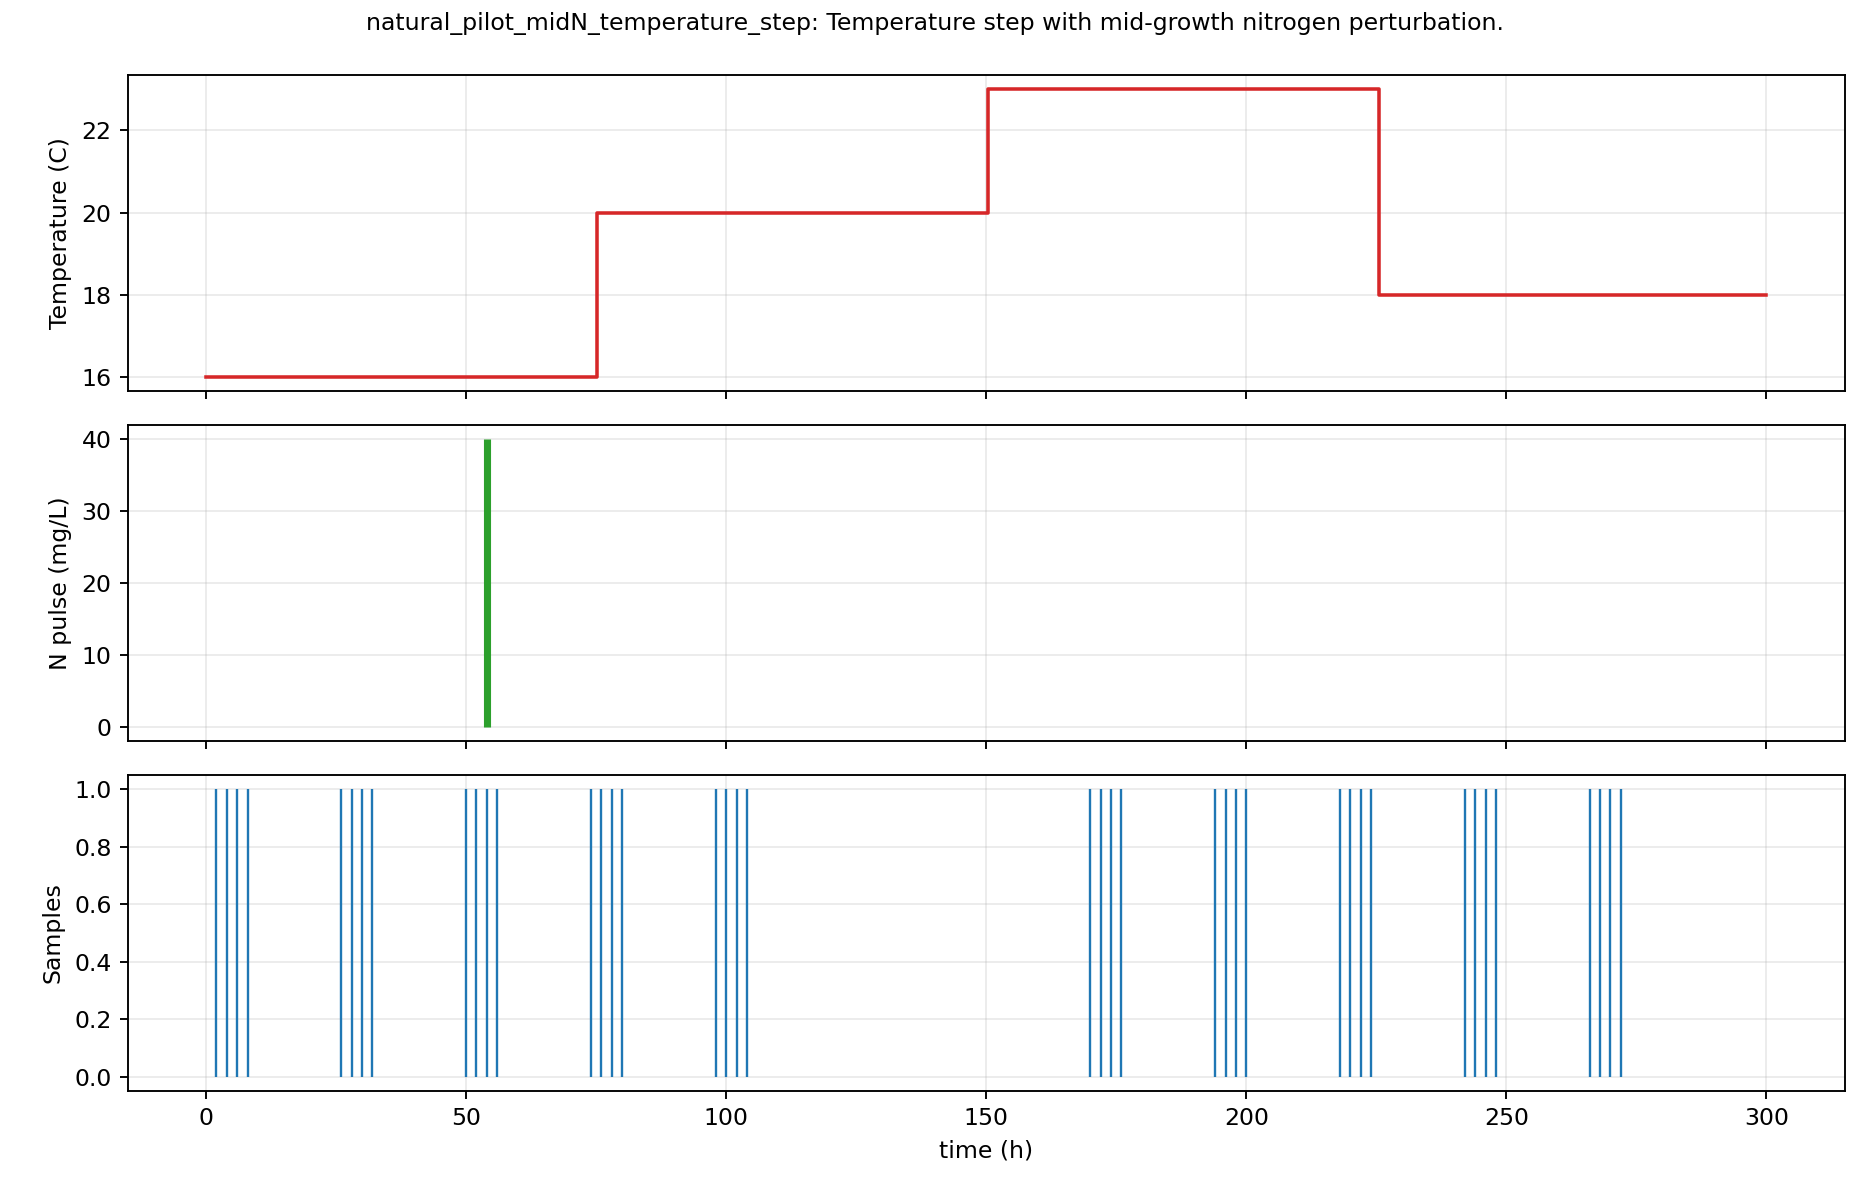

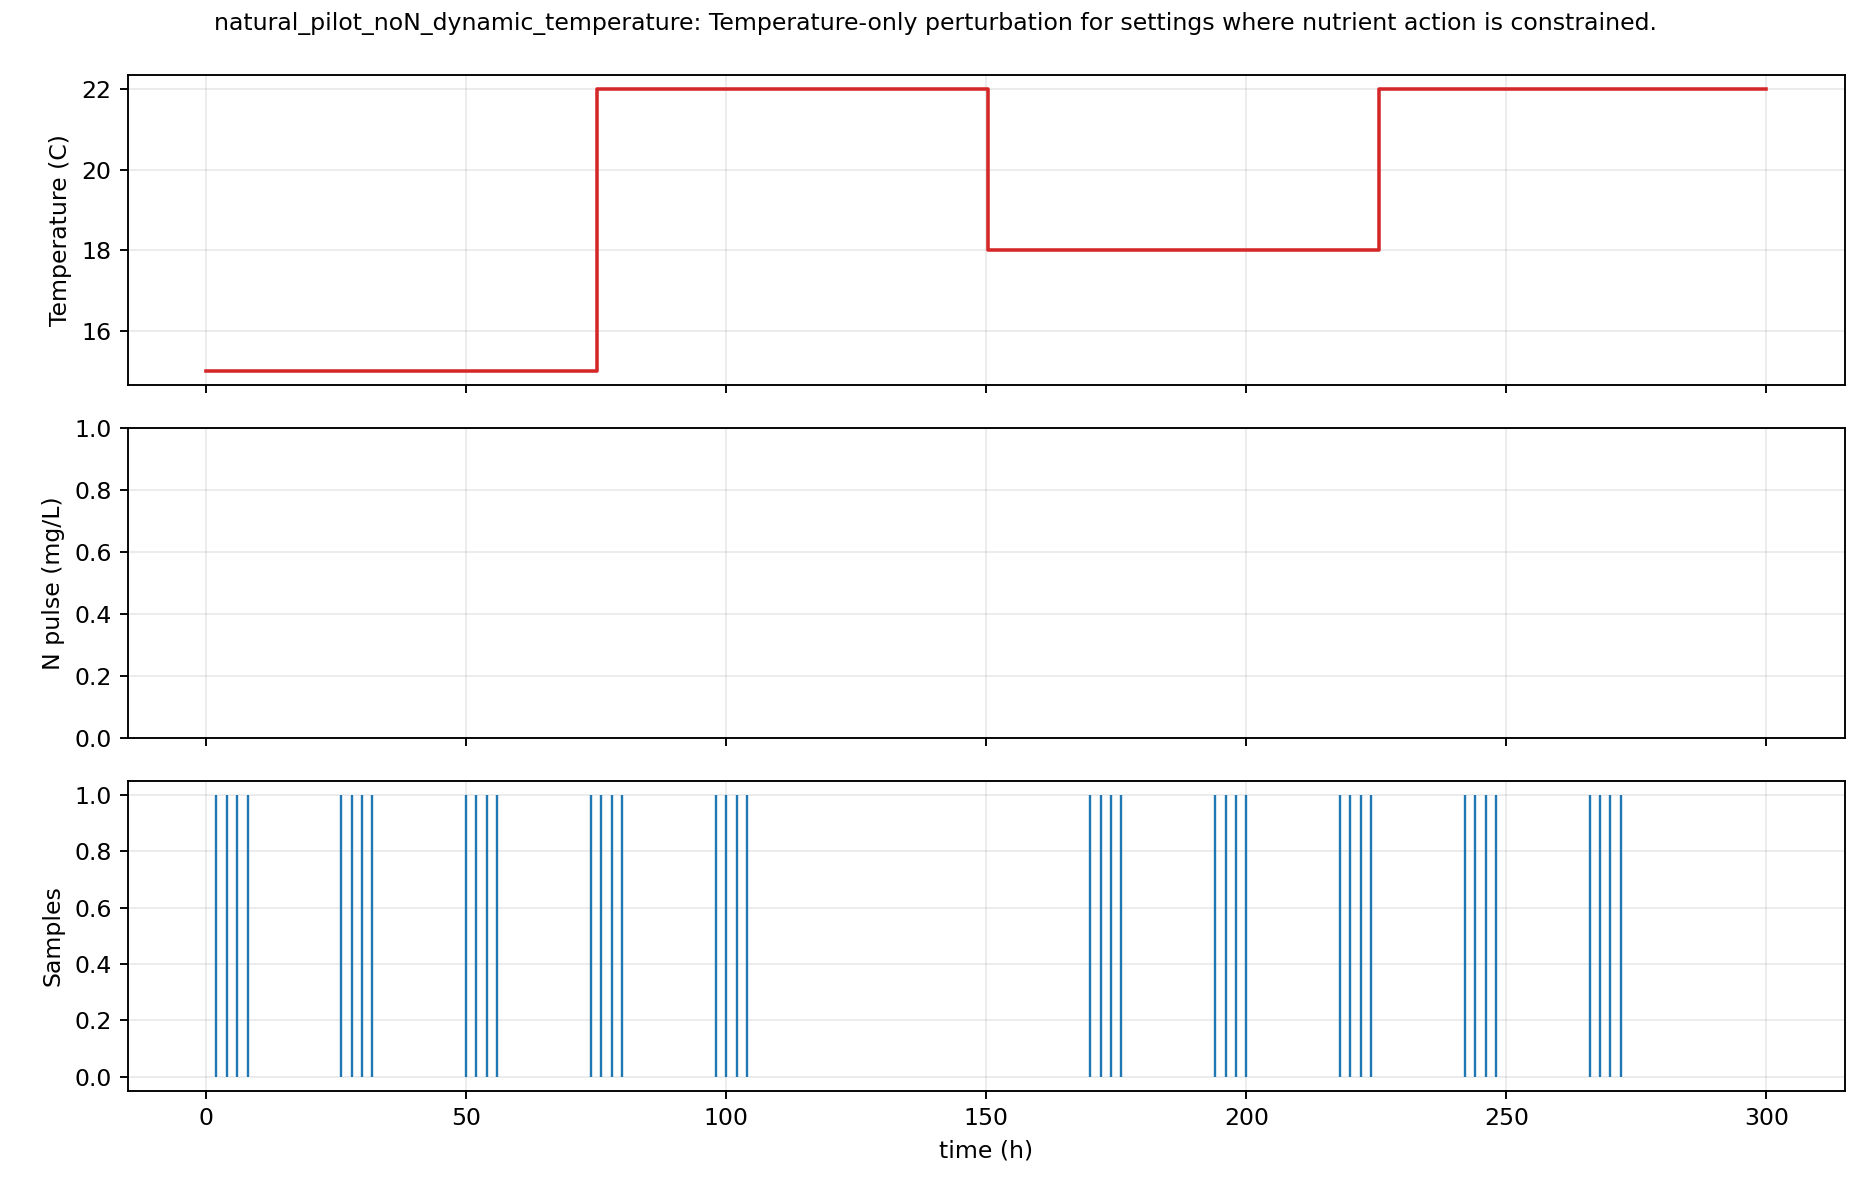

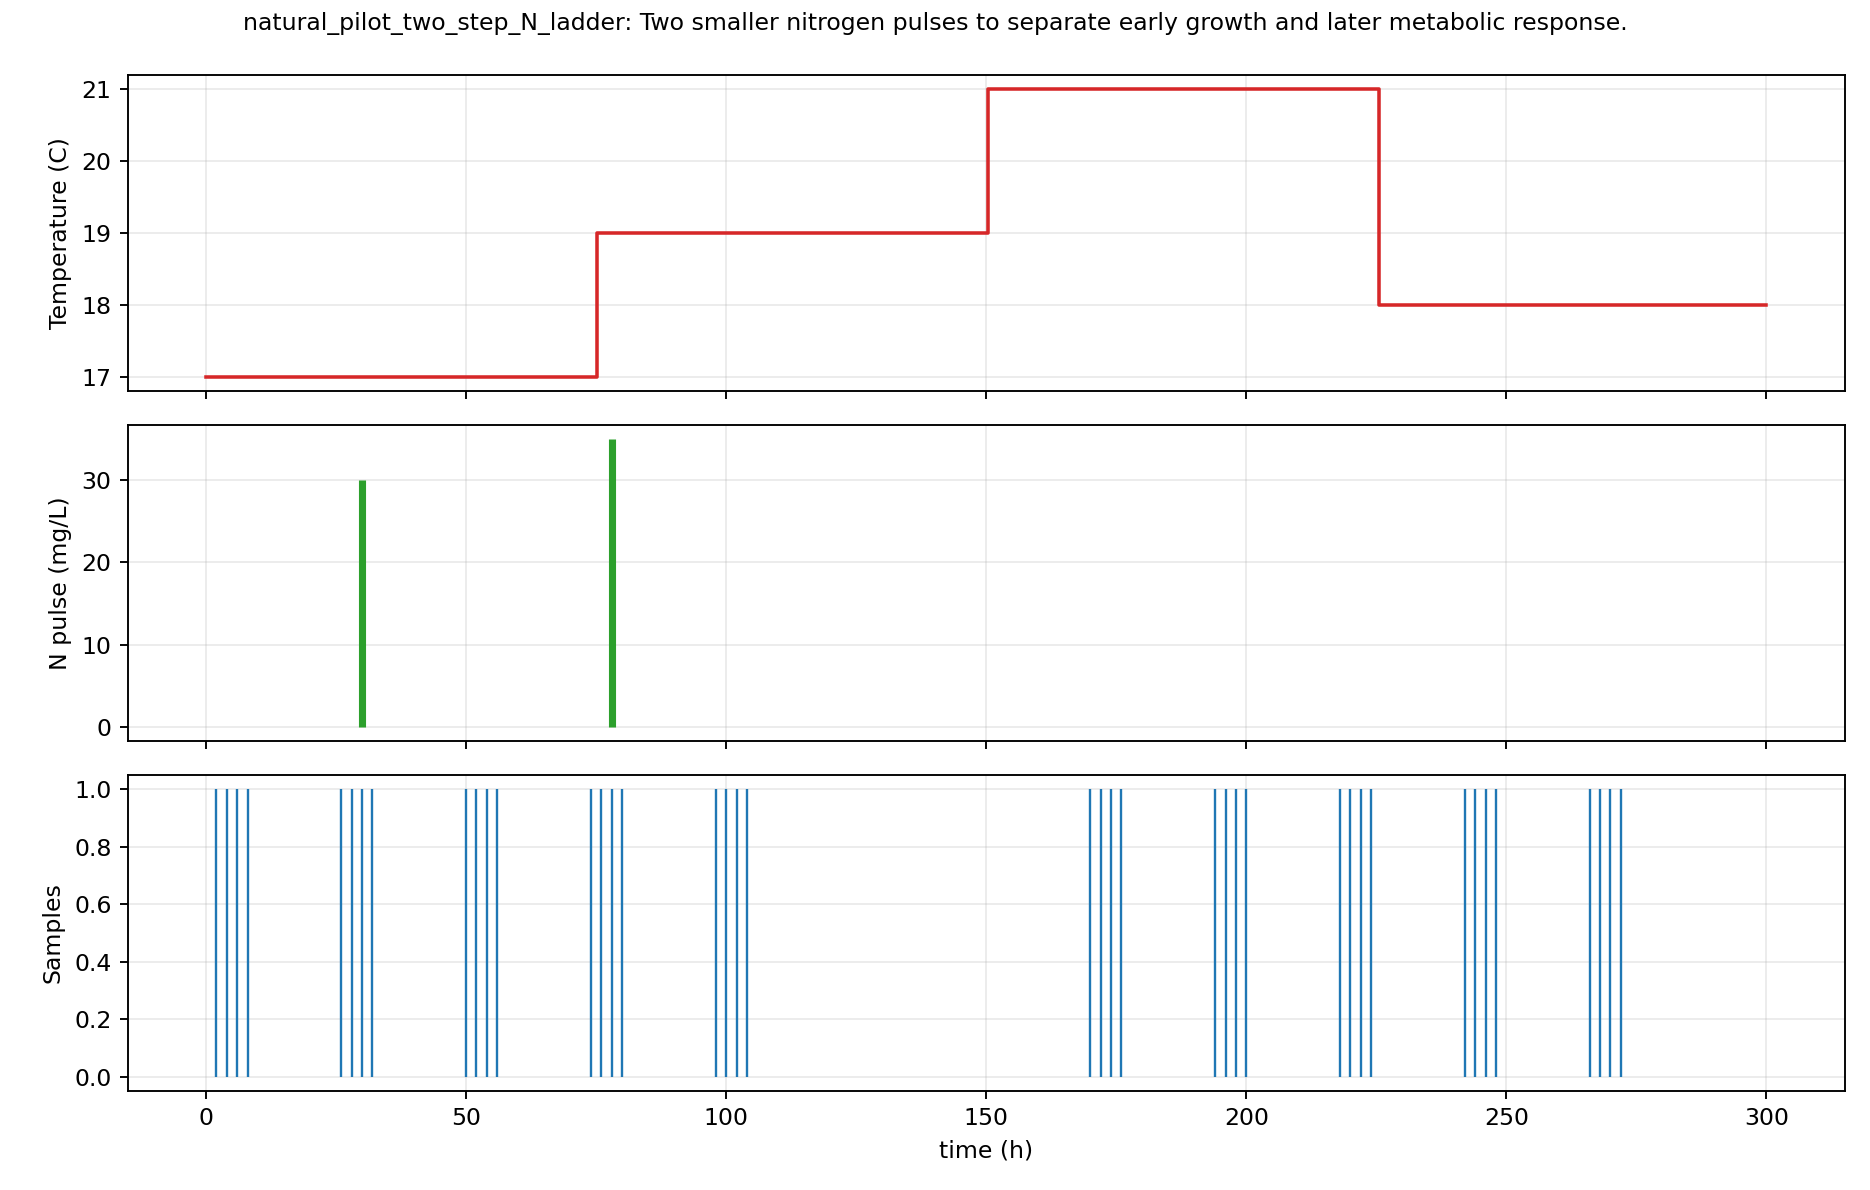

In [9]:
for path in sorted((RESULTS / 'plots' / 'designs').glob('candidate_inputs_*.png')):
    display(Image(filename=str(path)))

## Selected Model Aroma Fits

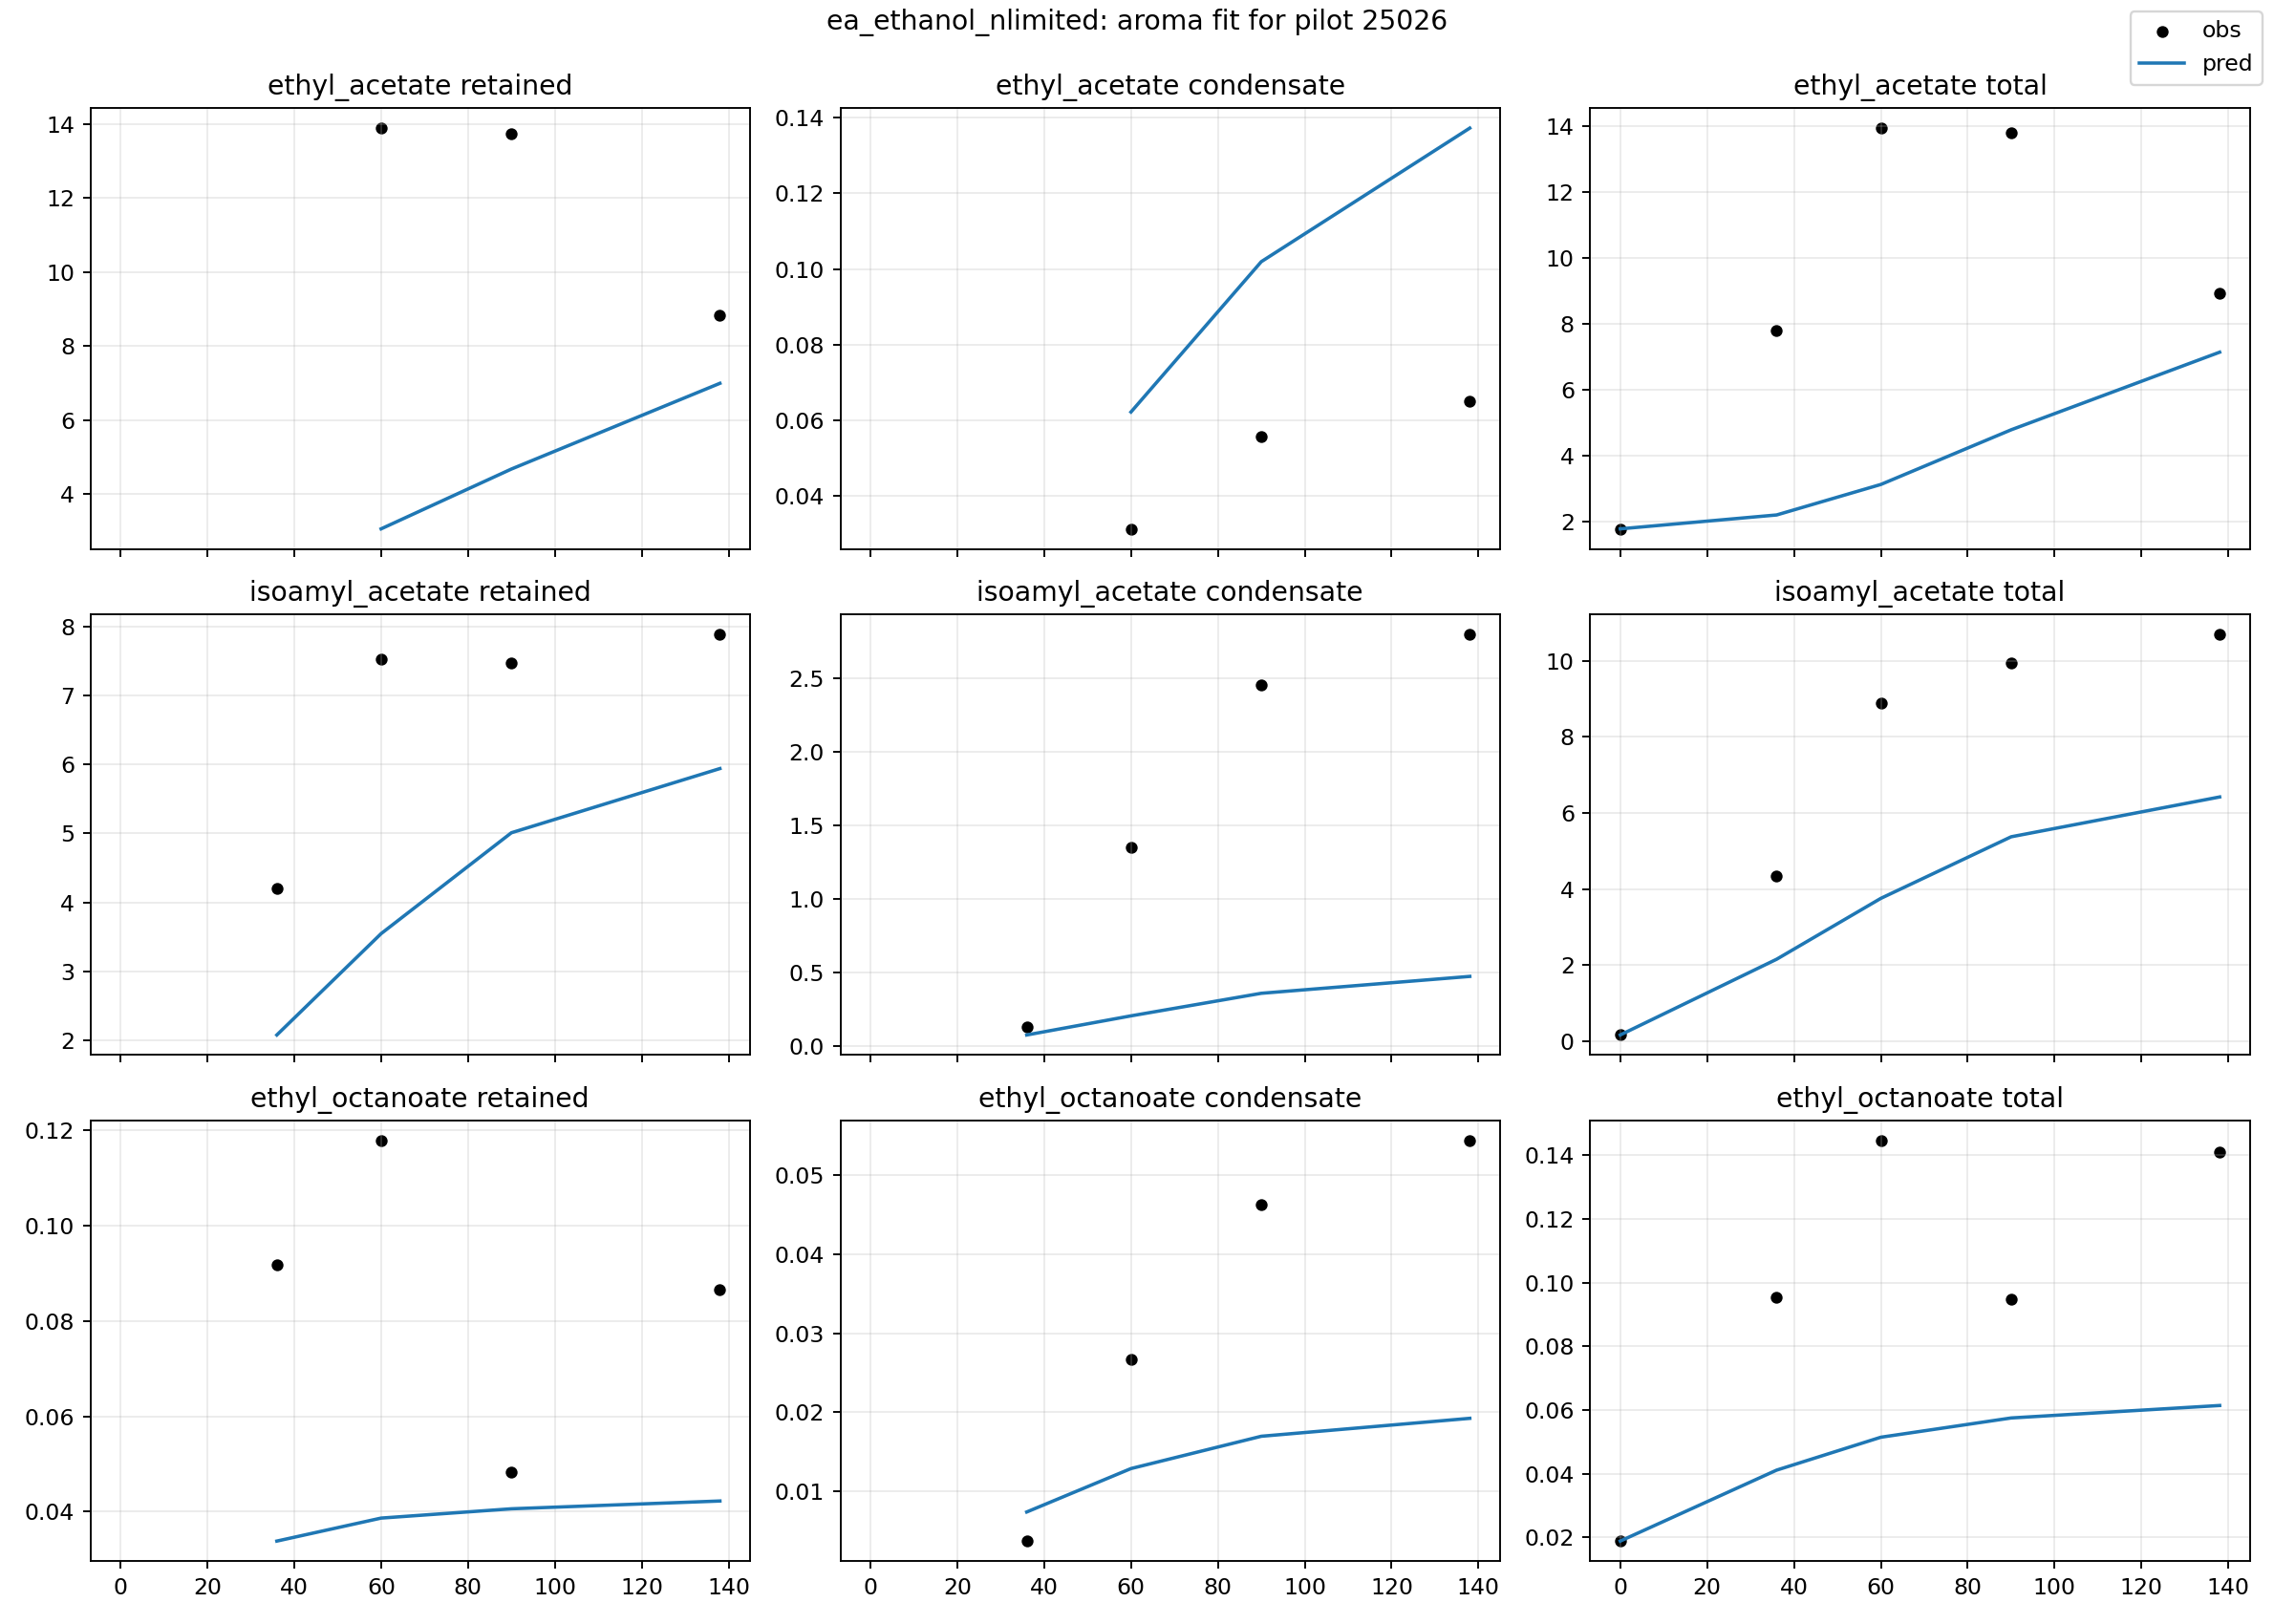

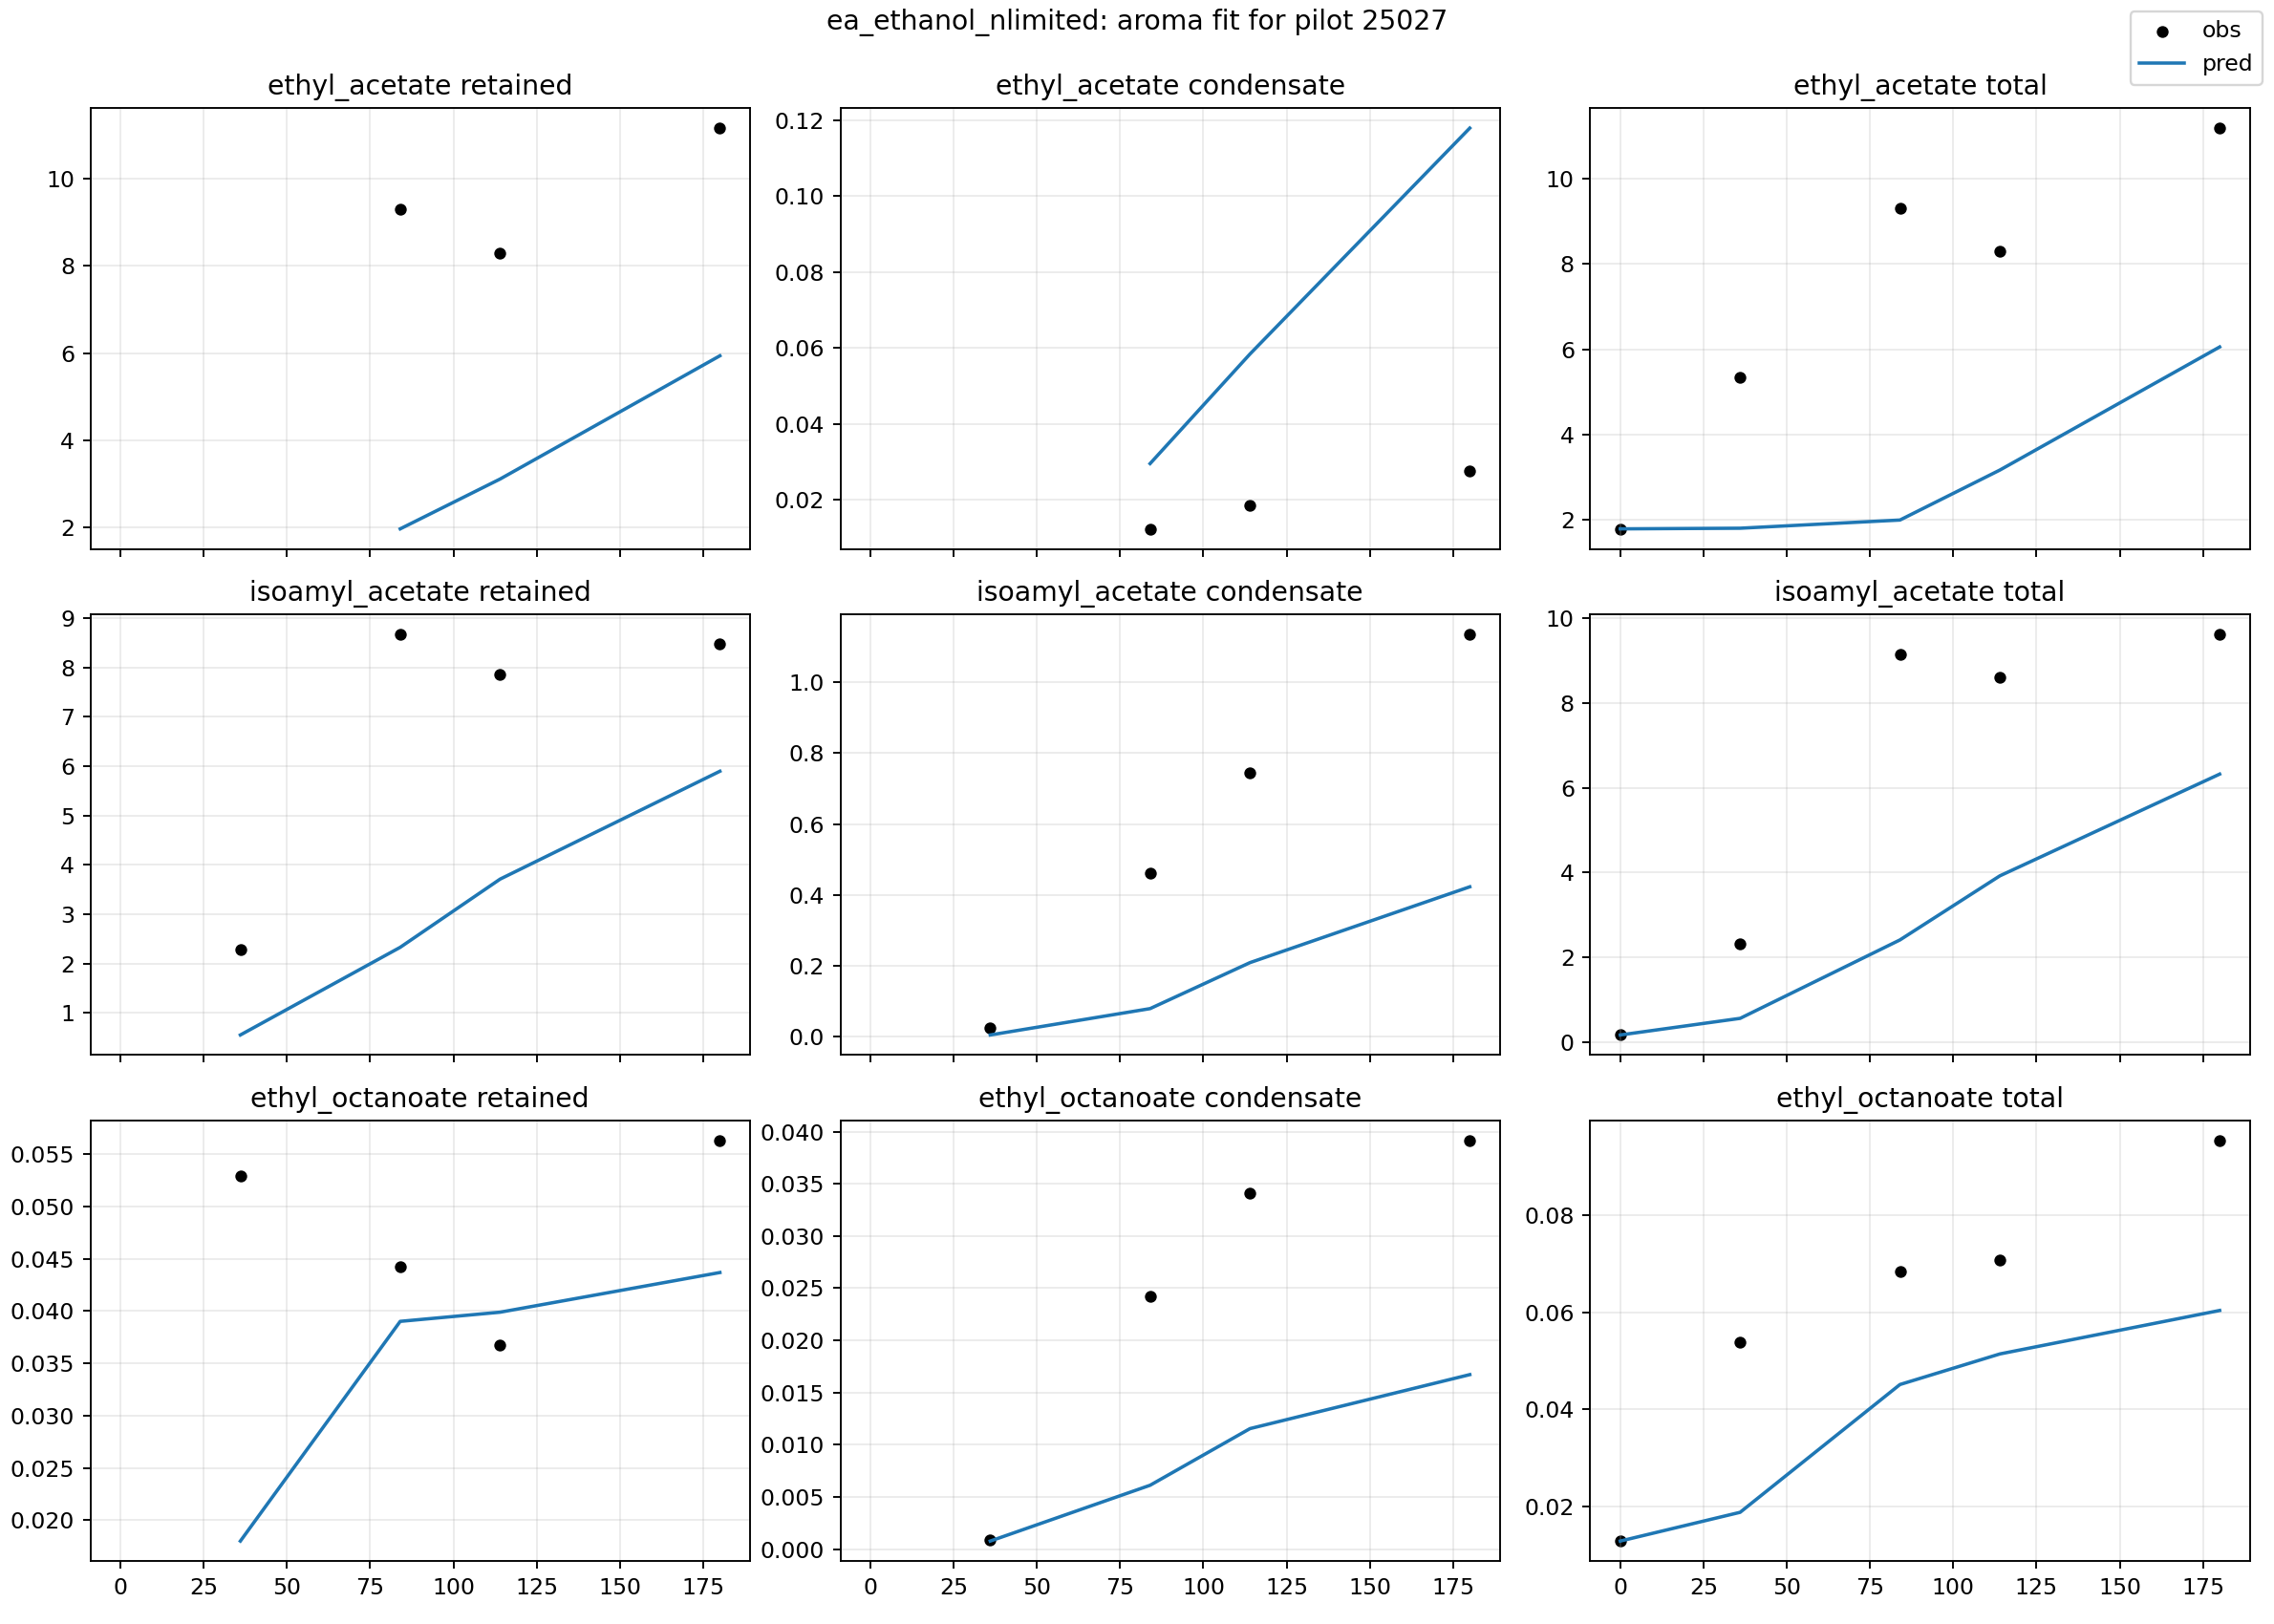

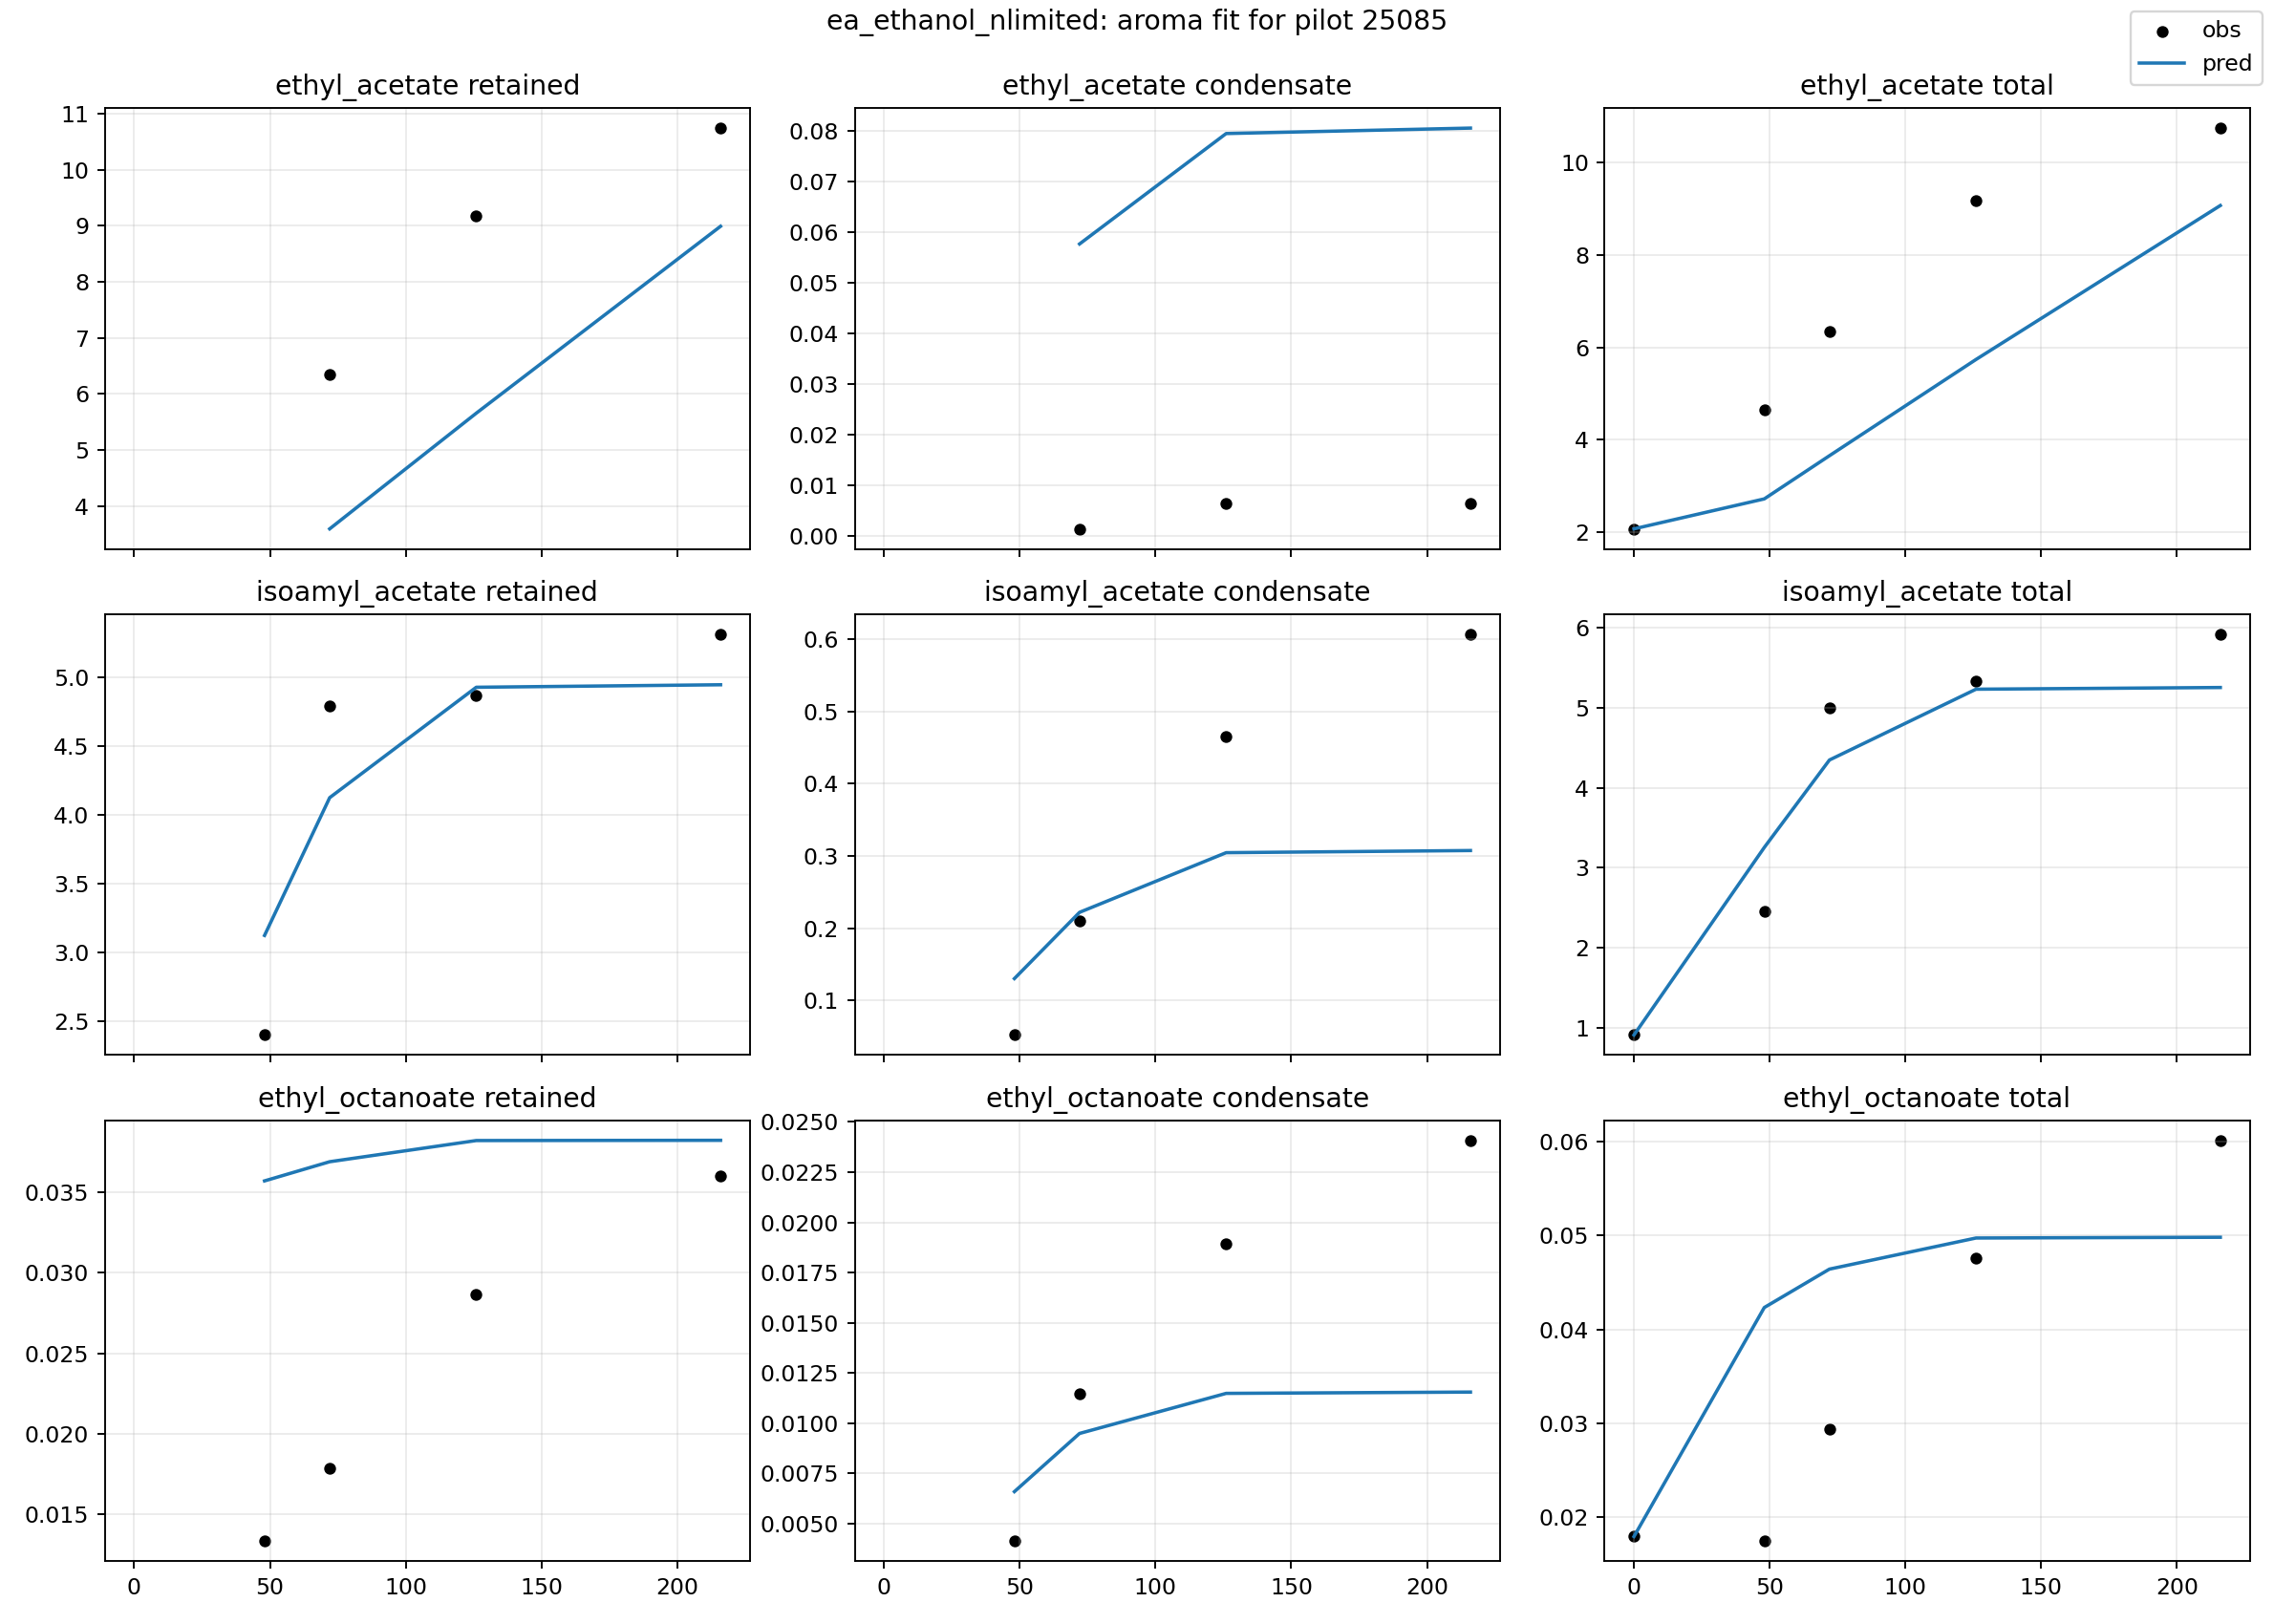

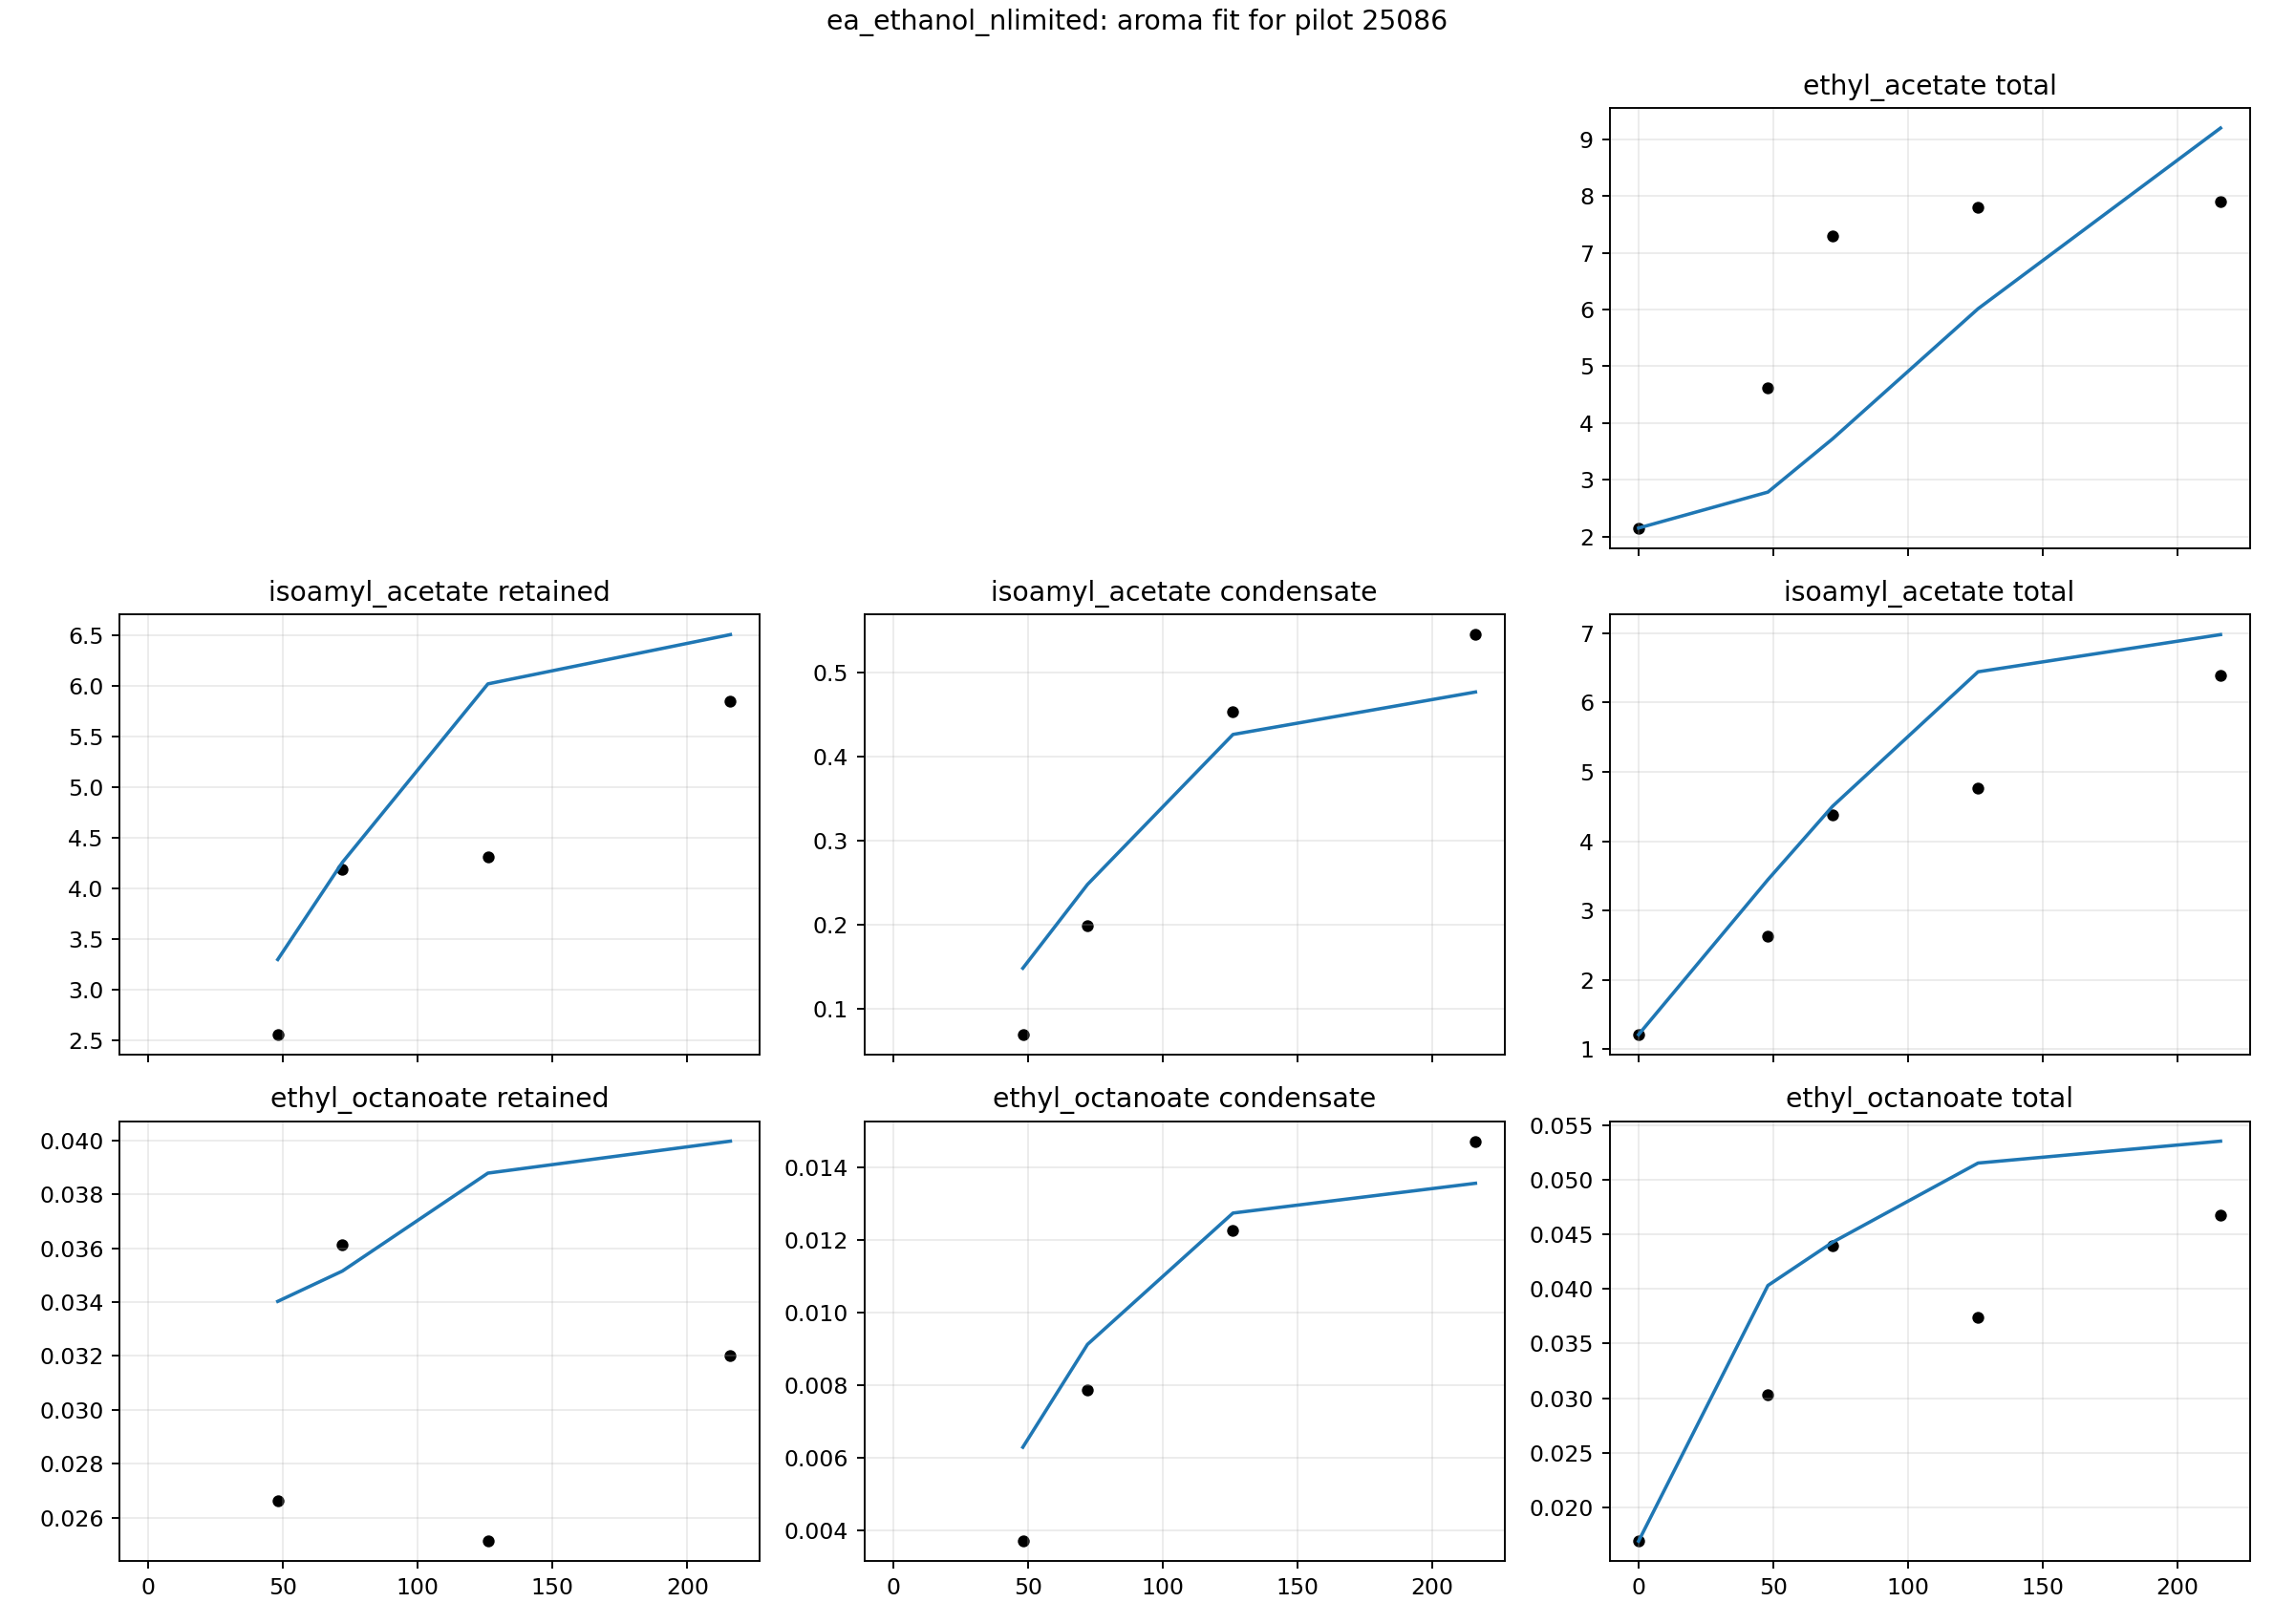

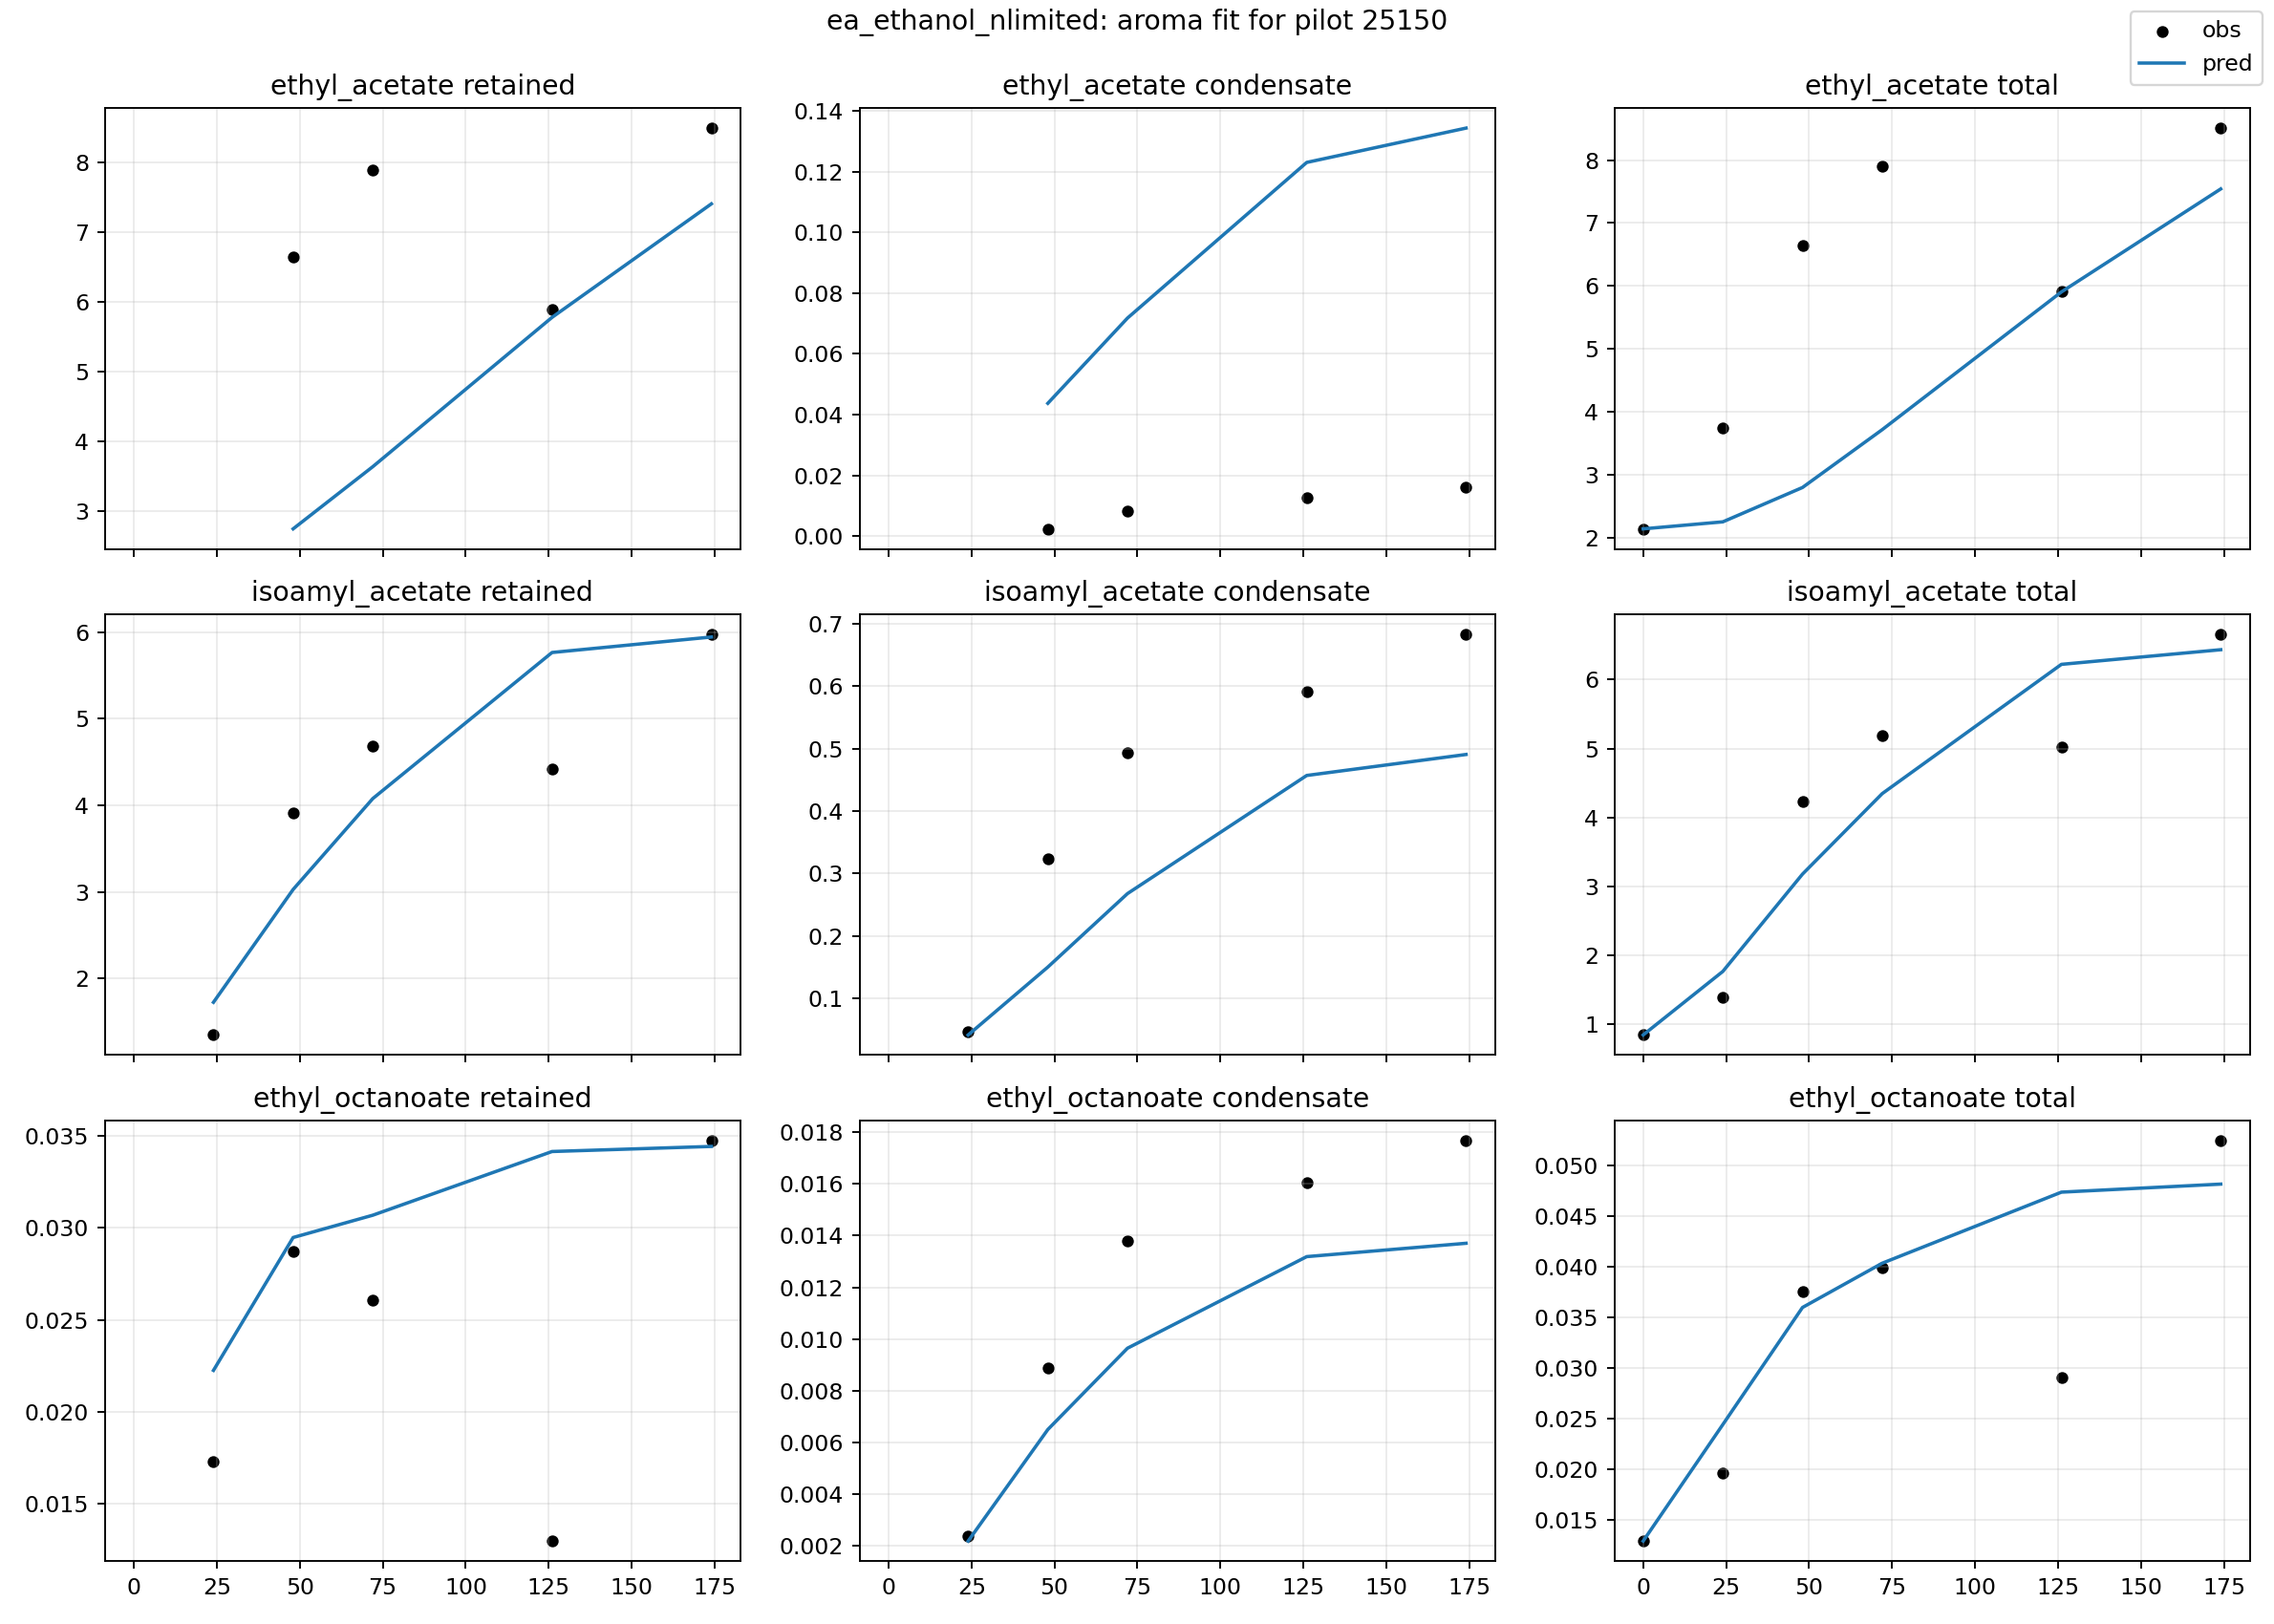

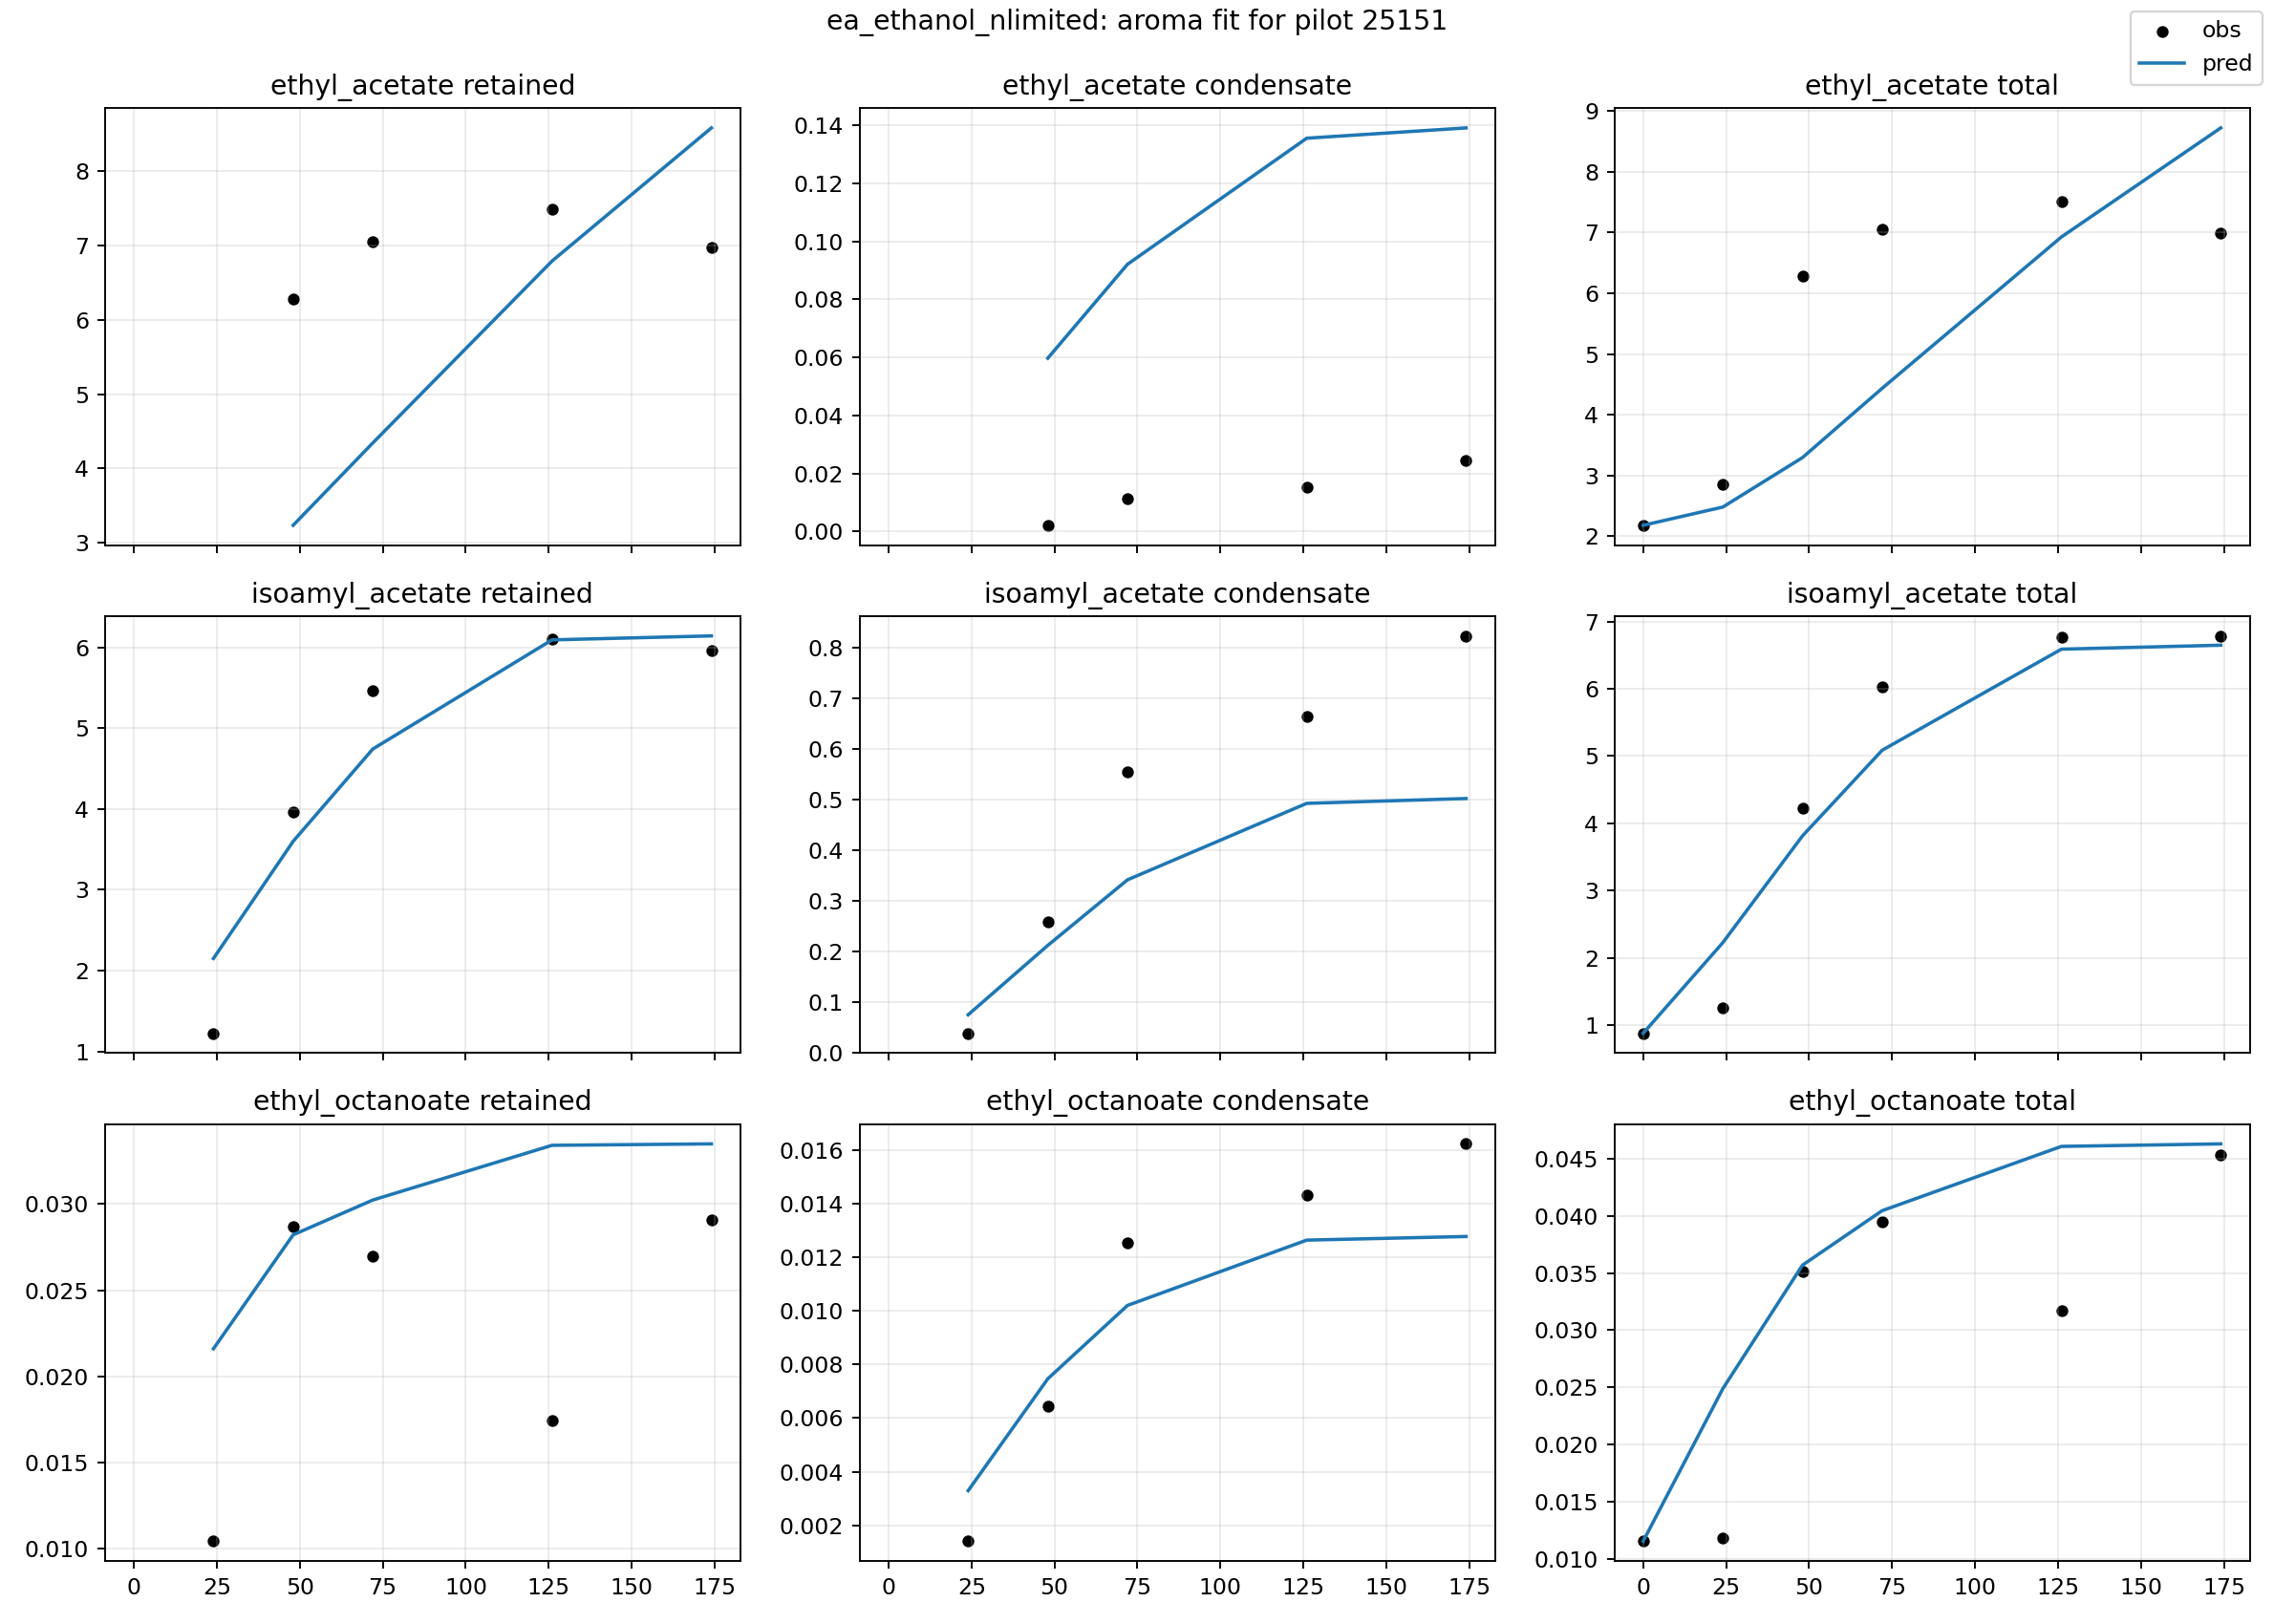

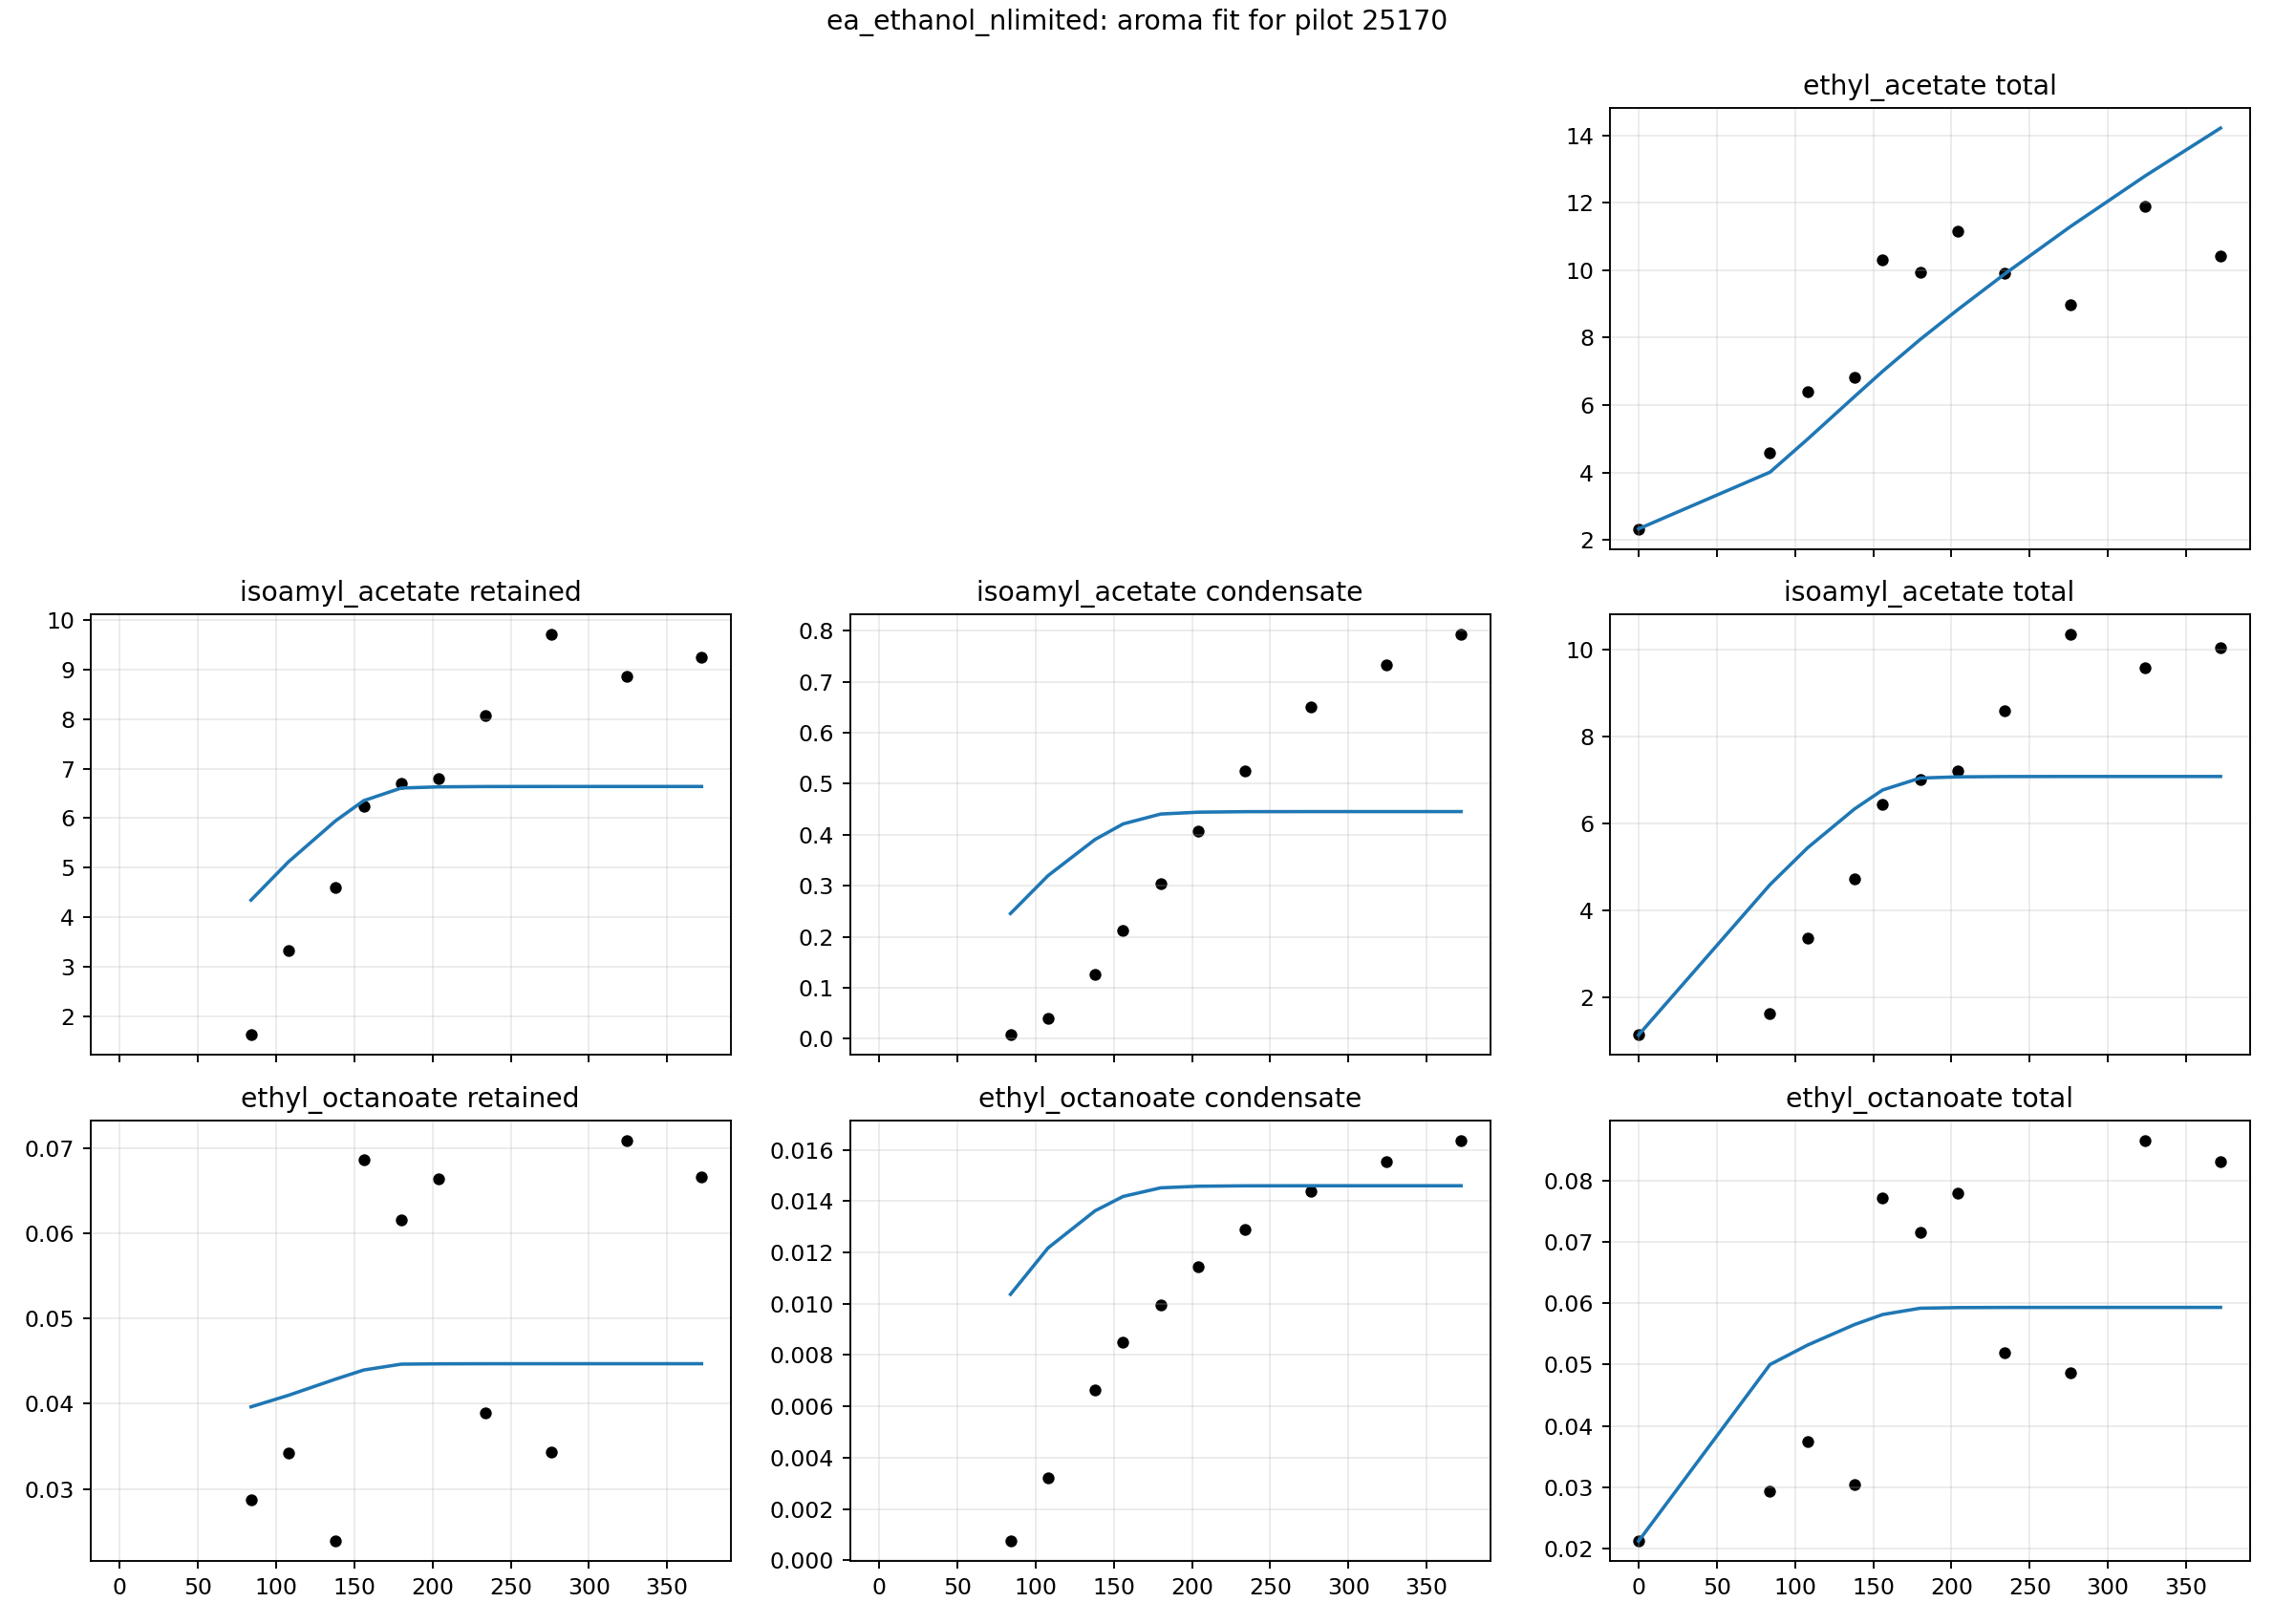

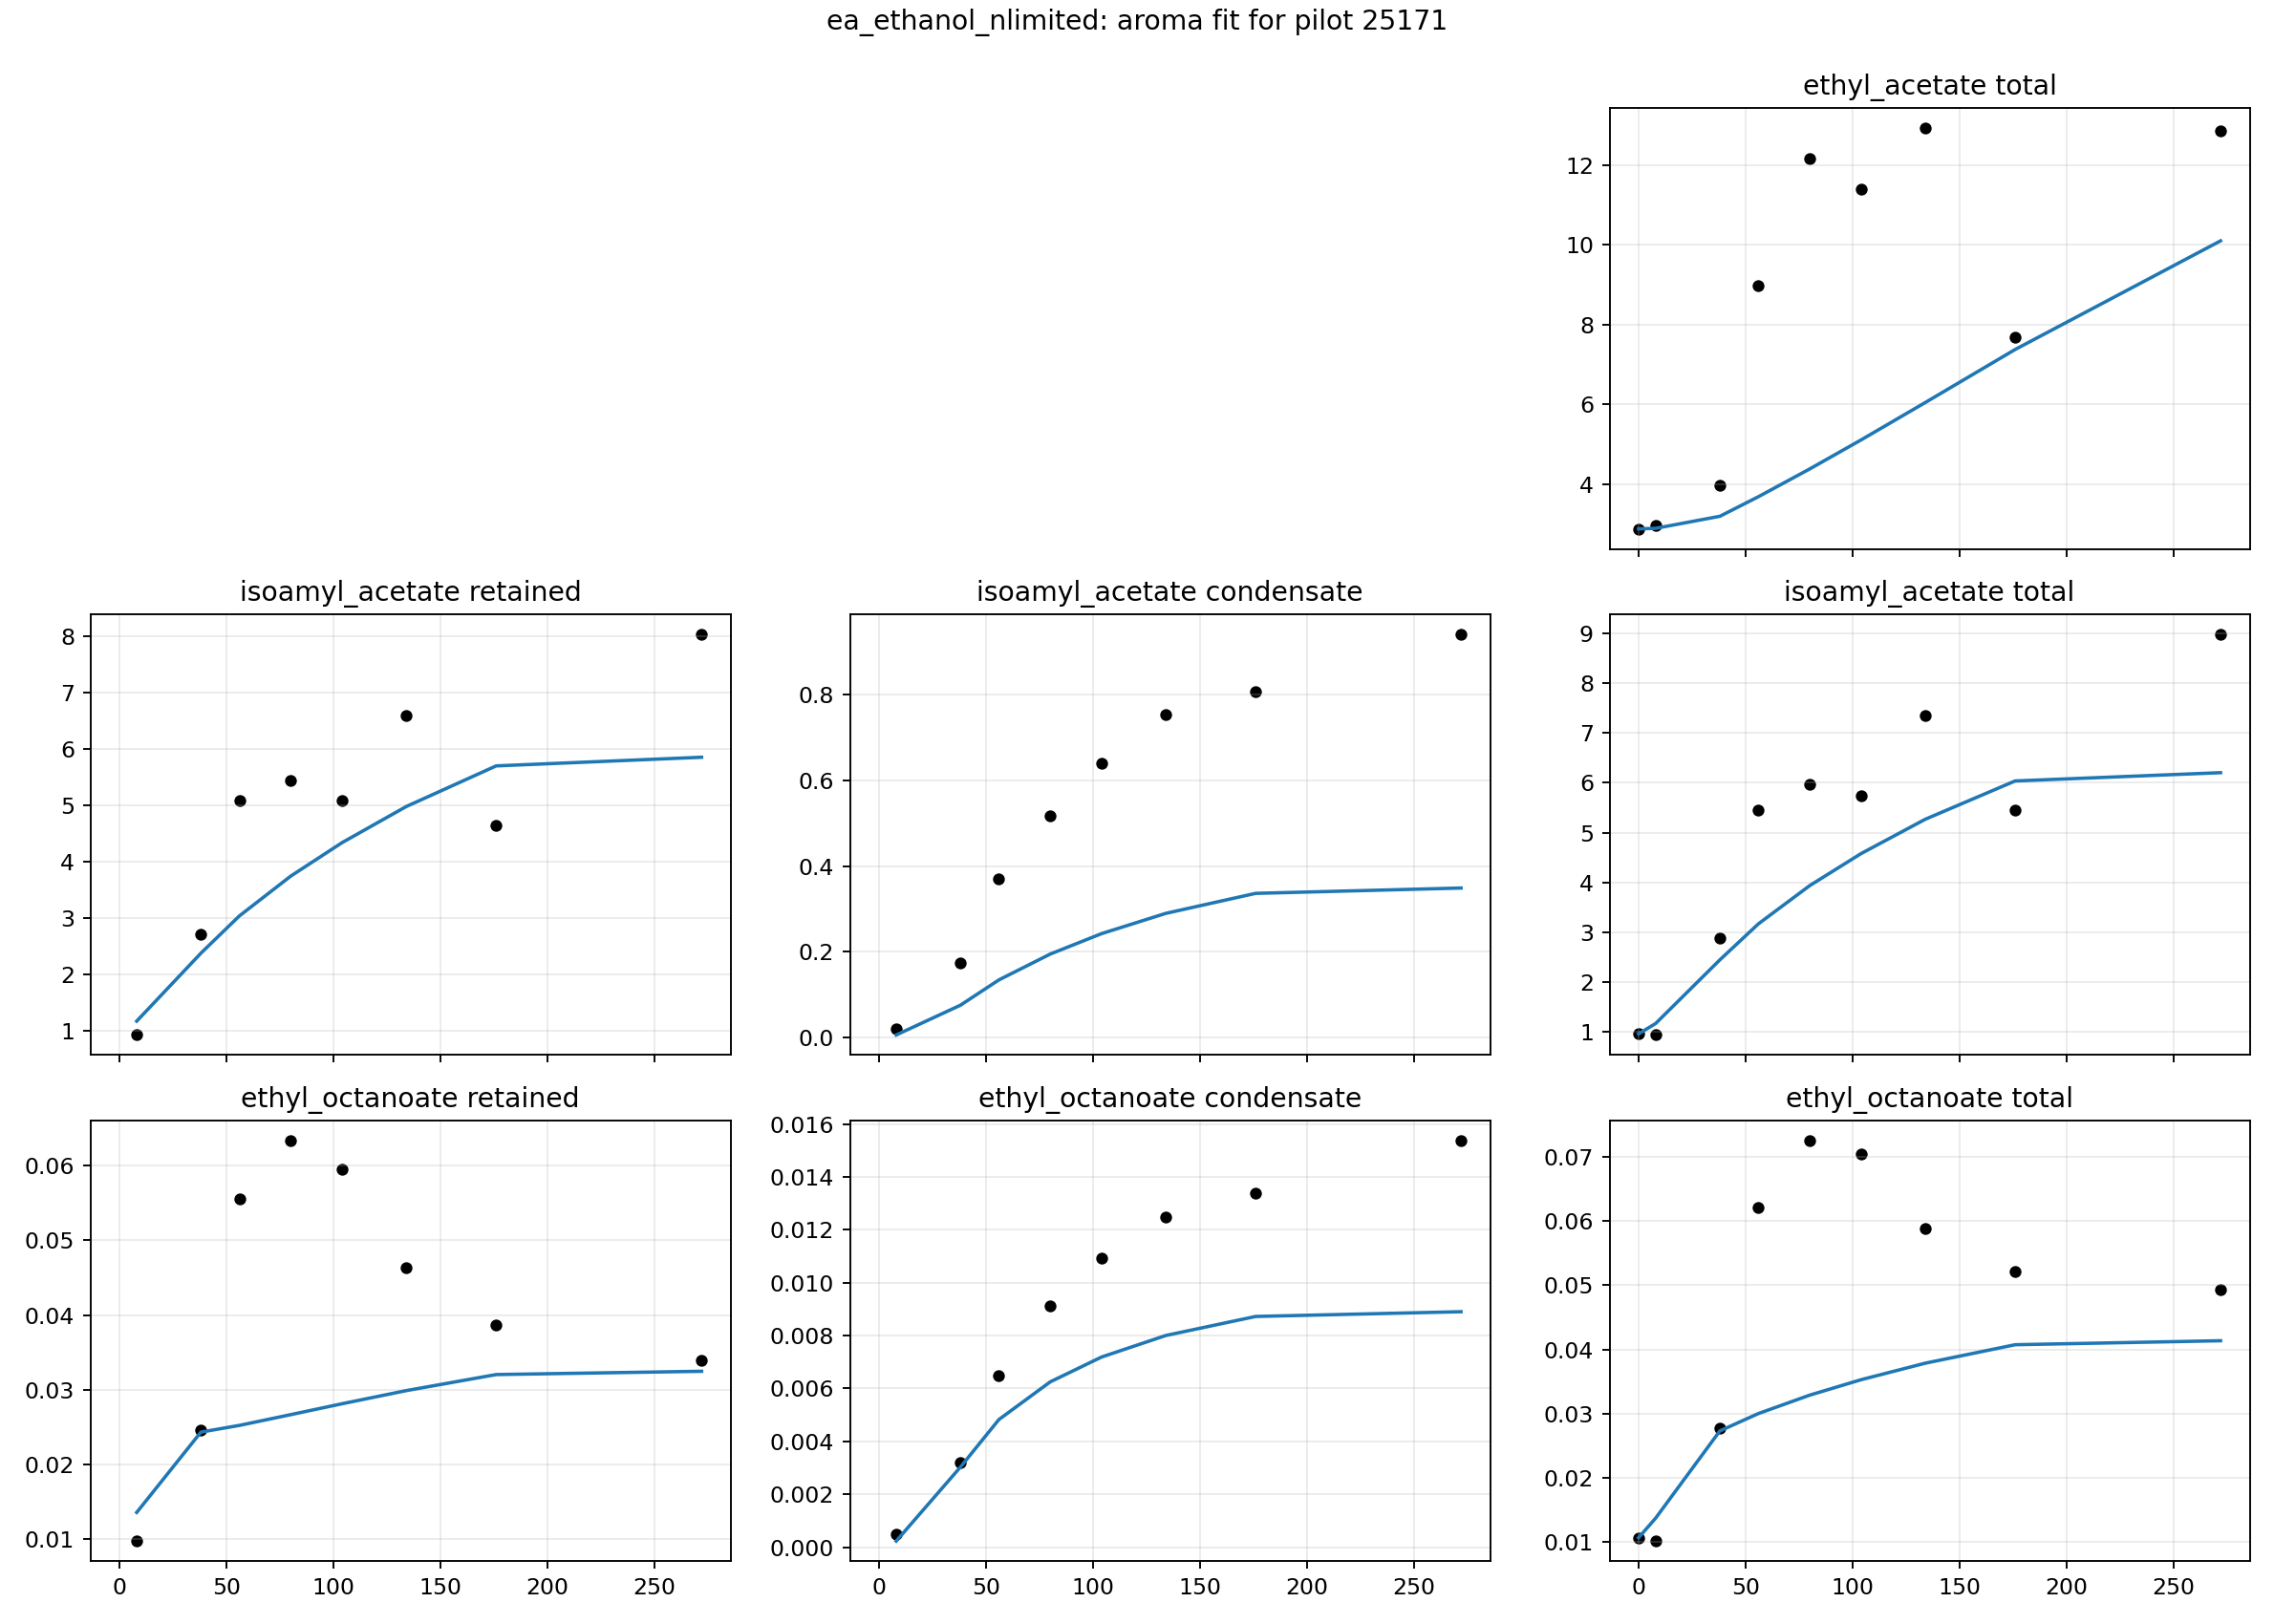

In [10]:
for path in sorted((RESULTS / 'plots' / 'selected_fit').glob('selected_aroma_fit_*.png')):
    display(Image(filename=str(path)))